<a href="https://colab.research.google.com/github/gustavosbarroso/PyPhysics/blob/main/PyPhysics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

plt.style.use('seaborn-v0_8-darkgrid')  # deixa bonito automático

MRUV

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def simular(a, v0, x0, m):
    t = np.linspace(0, 5, 100)

    x = x0 + v0*t + 0.5*a*t**2
    v = v0 + a*t
    a_vals = np.full_like(t, a)

    E = 0.5 * m * v**2   # energia cinética
    F = m * a            # força

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18,4))

    # Posição
    ax1.plot(t, x)
    ax1.set_title("x(t)")
    ax1.set_xlabel("t (s)")
    ax1.set_ylabel("x (m)")

    # Velocidade
    ax2.plot(t, v)
    ax2.set_title("v(t)")
    ax2.set_xlabel("t (s)")
    ax2.set_ylabel("v (m/s)")

    # Aceleração
    ax3.plot(t, a_vals)
    ax3.set_title("a(t)")
    ax3.set_xlabel("t (s)")
    ax3.set_ylabel("a (m/s²)")

    # Energia
    ax4.plot(t, E)
    ax4.set_title("E_c(t)")
    ax4.set_xlabel("t (s)")
    ax4.set_ylabel("Energia (J)")

    plt.suptitle(f"Força resultante: F = {F:.2f} N")
    plt.tight_layout()
    plt.show()

interact(
    simular,
    a=widgets.FloatSlider(min=-10, max=10, step=0.5, value=1, description='a'),
    v0=widgets.FloatSlider(min=-20, max=20, step=1, value=5, description='v₀'),
    x0=widgets.FloatSlider(min=-10, max=10, step=1, value=0, description='x₀'),
    m=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description='m')
);

interactive(children=(FloatSlider(value=1.0, description='a', max=10.0, min=-10.0, step=0.5), FloatSlider(valu…

Dinâmica de bloco-gráfico

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

g = 9.81
dt = 0.02

# =========================
# SIMULAÇÃO
# =========================
def gerar_dados(F0, mu_s, mu_k, m, tipo):

    t_max = 10
    t_vals = np.arange(0, t_max, dt)

    x = 0.0
    v = 0.0

    x_list = []
    v_list = []
    a_list = []

    for t in t_vals:

        if tipo == "Constante":
            F_aplicada = F0
        elif tipo == "Senoidal":
            F_aplicada = F0 * np.sin(t)
        elif tipo == "Impulso":
            F_aplicada = F0 if 2 < t < 2.5 else 0

        if abs(v) < 1e-4:
            F_max = mu_s * m * g

            if abs(F_aplicada) < F_max:
                F_atrito = -F_aplicada
            else:
                F_atrito = -np.sign(F_aplicada) * mu_k * m * g
        else:
            F_atrito = -np.sign(v) * mu_k * m * g

        F_total = F_aplicada + F_atrito

        a = F_total / m
        v += a * dt
        x += v * dt

        x_list.append(x)
        v_list.append(v)
        a_list.append(a)

    return t_vals, np.array(x_list), np.array(v_list), np.array(a_list)


# =========================
# GRÁFICO COM SLIDER
# =========================
def plot_grafico_slider(F0, mu_s, mu_k, m, tipo, frame):

    t_vals, x_vals, v_vals, a_vals = gerar_dados(F0, mu_s, mu_k, m, tipo)

    frame = min(frame, len(t_vals) - 1)
    t = t_vals[frame]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # =========================
    # POSIÇÃO
    # =========================
    ax1.plot(t_vals, x_vals)
    ax1.axvline(t, linestyle='--')

    # ponto atual
    ax1.plot(t, x_vals[frame], 'ro')

    ax1.set_title("Posição x(t)")
    ax1.set_xlabel("Tempo (s)")
    ax1.set_ylabel("x (m)")
    ax1.grid()

    # =========================
    # VELOCIDADE E ACELERAÇÃO
    # =========================
    ax2.plot(t_vals, v_vals, label="v(t) (m/s)")
    ax2.plot(t_vals, a_vals, label="a(t) (m/s^2)")

    ax2.axvline(t, linestyle='--')

    # ponto atual
    ax2.plot(t, v_vals[frame], 'ro', label="v atual")
    ax2.plot(t, a_vals[frame], 'go', label="a atual")

    ax2.set_title("Velocidade e Aceleração")
    ax2.set_xlabel("Tempo (s)")
    ax2.set_ylabel("Grandeza")
    ax2.legend()
    ax2.grid()

    plt.suptitle(f"t = {t:.2f}s", fontsize=12)

    plt.tight_layout()
    plt.show()


# =========================
# CONTROLES
# =========================
widgets.interact(
    plot_grafico_slider,

    F0=widgets.FloatSlider(value=5, min=-10, max=10, step=0.1),
    mu_s=widgets.FloatSlider(value=0.4, min=0, max=1, step=0.01),
    mu_k=widgets.FloatSlider(value=0.3, min=0, max=1, step=0.01),
    m=widgets.FloatSlider(value=1.0, min=0.1, max=10, step=0.1),

    tipo=widgets.Dropdown(options=["Constante", "Senoidal", "Impulso"]),

    frame=widgets.IntSlider(min=0, max=500, step=1, value=0, description="Tempo")
)

interactive(children=(FloatSlider(value=5.0, description='F0', max=10.0, min=-10.0), FloatSlider(value=0.4, de…

<function __main__.plot_grafico_slider(F0, mu_s, mu_k, m, tipo, frame)>

Dinâmica de bloco- animação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

g = 9.81
dt = 0.02

# =========================
# SIMULAÇÃO
# =========================
def gerar_dados(F0, mu_s, mu_k, m, tipo):

    t_max = 10
    t_vals = np.arange(0, t_max, dt)

    x = 0.0
    v = 0.0

    x_list = []
    v_list = []
    a_list = []
    atrito_tipo = []

    for t in t_vals:

        if tipo == "Constante":
            F_aplicada = F0
        elif tipo == "Senoidal":
            F_aplicada = F0 * np.sin(t)
        elif tipo == "Impulso":
            F_aplicada = F0 if 2 < t < 2.5 else 0

        if abs(v) < 1e-4:
            F_max = mu_s * m * g

            if abs(F_aplicada) < F_max:
                F_atrito = -F_aplicada
                tipo_atrito = "Estático"
            else:
                F_atrito = -np.sign(F_aplicada) * mu_k * m * g
                tipo_atrito = "Cinético"
        else:
            F_atrito = -np.sign(v) * mu_k * m * g
            tipo_atrito = "Cinético"

        if abs(F_atrito) < 1e-6:
            tipo_atrito = "Zerado"

        F_total = F_aplicada + F_atrito

        a = F_total / m
        v += a * dt
        x += v * dt

        x_list.append(x)
        v_list.append(v)
        a_list.append(a)
        atrito_tipo.append(tipo_atrito)

    return t_vals, np.array(x_list), np.array(v_list), np.array(a_list), atrito_tipo


# =========================
# ANIMAÇÃO
# =========================
def animar_bloco(F0, mu_s, mu_k, m, tipo, frame):

    t_vals, x_vals, v_vals, a_vals, atrito_tipo = gerar_dados(F0, mu_s, mu_k, m, tipo)

    frame = min(frame, len(t_vals) - 1)

    t = t_vals[frame]
    x = x_vals[frame]
    v = v_vals[frame]

    tipo_atrito = atrito_tipo[frame]

    # força aplicada
    if tipo == "Constante":
        F_aplicada = F0
    elif tipo == "Senoidal":
        F_aplicada = F0 * np.sin(t)
    elif tipo == "Impulso":
        F_aplicada = F0 if 2 < t < 2.5 else 0

    # atrito
    if abs(v) < 1e-4:
        F_max = mu_s * m * g

        if abs(F_aplicada) < F_max:
            F_atrito = -F_aplicada
        else:
            F_atrito = -np.sign(F_aplicada) * mu_k * m * g
    else:
        F_atrito = -np.sign(v) * mu_k * m * g

    scale = 0.2

    fig, ax = plt.subplots(figsize=(10, 3))

    # câmera dinâmica
    window = 6
    ax.set_xlim(x - window/2, x + window/2)
    ax.set_ylim(-1, 1)

    # bloco
    ax.plot(x, 0, 's', markersize=20)

    # forças
    ax.arrow(x, 0.2, scale * F_aplicada, 0,
             head_width=0.05, color='green')

    ax.arrow(x, -0.2, scale * F_atrito, 0,
             head_width=0.05, color='red')

    ax.arrow(x, 0, 0.1 * v, 0,
             head_width=0.05, color='blue')

    # =========================
    # LEGENDA DAS FORÇAS
    # =========================
    ax.legend(handles=[
        plt.Line2D([0], [0], color='green', lw=2, label='Força aplicada (N)'),
        plt.Line2D([0], [0], color='red', lw=2, label='Atrito (N)'),
        plt.Line2D([0], [0], color='blue', lw=2, label='Velocidade(m/s)')
    ], loc='upper left')

    # =========================
    # TEXTO DO ATRITO
    # =========================
    ax.text(0.02, 0.05, f"Atrito: {tipo_atrito}",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.7))
    ax.set_title(f"Bloco em movimento | t = {t:.2f}s")
    ax.set_yticks([])
    ax.set_xlabel("Posição (m)")
    ax.grid()

    plt.show()


# =========================
# CONTROLES
# =========================
widgets.interact(
    animar_bloco,

    F0=widgets.FloatSlider(value=5, min=-10, max=10, step=0.1, description="Força (N)"),
    mu_s=widgets.FloatSlider(value=0.4, min=0, max=1, step=0.01, description="μ estático"),
    mu_k=widgets.FloatSlider(value=0.3, min=0, max=1, step=0.01, description="μ cinético"),
    m=widgets.FloatSlider(value=1.0, min=0.1, max=10, step=0.1, description="Massa (kg)"),

    tipo=widgets.Dropdown(
        options=["Constante", "Senoidal", "Impulso"],
        description="Tipo"
    ),

    frame=widgets.IntSlider(min=0, max=500, step=1, value=0, description="Tempo")
)

interactive(children=(FloatSlider(value=5.0, description='Força (N)', max=10.0, min=-10.0), FloatSlider(value=…

<function __main__.animar_bloco(F0, mu_s, mu_k, m, tipo, frame)>

Plano inclinado-gráfico

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

g = 9.81

# =========================
# SIMULAÇÃO
# =========================
def simular(theta_deg, tipo, v0):

    theta = np.radians(theta_deg)

    # fator I/(mR²)
    k_dict = {
        "Bloco": 0,
        "Esfera": 2/5,
        "Cilindro": 1/2,
        "Anel": 1
    }

    k = k_dict[tipo]

    a = g * np.sin(theta) / (1 + k)

    dt = 0.02
    t_max = 10
    t = np.arange(0, t_max, dt)

    x = 0
    v = v0

    x_vals = []
    v_vals = []
    E_trans = []
    E_rot = []
    E_pot = []

    m = 1

    for _ in t:

        v = v + a * dt
        x = x + v * dt

        h = x * np.sin(theta)

        E_t = 0.5 * m * v**2
        E_r = 0.5 * k * m * v**2  # 🔥 bloco → isso zera automaticamente
        E_p = m * g * h

        x_vals.append(x)
        v_vals.append(v)
        E_trans.append(E_t)
        E_rot.append(E_r)
        E_pot.append(E_p)

    return t, x_vals, v_vals, E_trans, E_rot, E_pot


# =========================
# PLOT
# =========================
def plotar(theta, tipo, v0):

    t, x, v, Et, Er, Ep = simular(theta, tipo, v0)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # posição
    axs[0].plot(t, x)
    axs[0].set_title(f"Posição ({tipo})")
    axs[0].set_xlabel("Tempo (s)")
    axs[0].set_ylabel("Posição (m)")
    axs[0].grid()

    # velocidade
    axs[1].plot(t, v)
    axs[1].set_title(f"Velocidade ({tipo})")
    axs[1].set_xlabel("Tempo (s)")
    axs[1].set_ylabel("Velocidade (m/s)")
    axs[1].grid()

    # energias
    axs[2].plot(t, Et, label="Translacional")
    axs[2].plot(t, Er, label="Rotacional")
    axs[2].plot(t, Ep, label="Potencial")
    axs[2].plot(t, np.array(Et)+np.array(Er)+np.array(Ep), '--', label="Total")

    axs[2].set_title(f"Energias ({tipo})")
    axs[2].set_xlabel("Tempo (s)")
    axs[2].set_ylabel("Energia (J)")
    axs[2].legend()
    axs[2].grid()

    plt.tight_layout()
    plt.show()


# =========================
# INTERFACE
# =========================
widgets.interact(
    plotar,
    theta=widgets.FloatSlider(min=5, max=60, step=1, value=20, description="Ângulo (°)"),
    tipo=widgets.Dropdown(
        options=["Bloco", "Esfera", "Cilindro", "Anel"],
        description="Sólido"
    ),
    v0=widgets.FloatSlider(min=-10, max=10, step=0.5, value=0, description="Vel. inicial")
)

Plano inclinado-animação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

g = 9.81

# =========================
# SIMULAÇÃO
# =========================
def simular_solido(theta_deg, k):

    theta = np.radians(theta_deg)
    a = g * np.sin(theta) / (1 + k)

    dt = 0.02
    t_max = 10
    t = np.arange(0, t_max, dt)

    x = 0
    v = 0

    x_vals = []

    for _ in t:
        v = v + a * dt
        x = x + v * dt
        x_vals.append(x)

    return t, np.array(x_vals)


# =========================
# VISUALIZAÇÃO
# =========================
def visualizar(theta, tempo):

    solidos = {
        "Bloco": {"k": 0, "cor": "purple"},
        "Esfera": {"k": 2/5, "cor": "blue"},
        "Cilindro": {"k": 1/2, "cor": "green"},
        "Anel": {"k": 1, "cor": "red"}
    }

    resultados = {}
    for nome, props in solidos.items():
        t, x = simular_solido(theta, props["k"])
        resultados[nome] = x

    idx = int(tempo / 0.02)

    theta_rad = np.radians(theta)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # =========================
    # PLANO INCLINADO
    # =========================
    L = 10
    H = L * np.tan(theta_rad)

    x_plano = np.linspace(0, L, 100)
    y_plano = H - x_plano * np.tan(theta_rad)

    ax1.plot(x_plano, y_plano, color="black")

    ax1.set_xlim(0, L)
    ax1.set_ylim(0, H + 1)
    ax1.set_title("Descida no plano inclinado")
    ax1.set_xlabel("Deslocamento (m)")
    ax1.set_ylabel("Altura (m)")
    ax1.grid()

    R = 0.4

    # =========================
    # GRÁFICO
    # =========================
    ax2.set_title("Posição vs Tempo")
    ax2.set_xlabel("Tempo (s)")
    ax2.set_ylabel("Posição (m)")
    ax2.grid()

    for nome, props in solidos.items():

        cor = props["cor"]
        x_vals = resultados[nome]

        xpos = x_vals[idx]
        ypos = H - xpos * np.tan(theta_rad) + R

        # 🔥 BLOCO (sem rotação)
        if nome == "Bloco":
            lado = 2 * R
            bloco = plt.Rectangle(
                (xpos - R, ypos - R),
                lado,
                lado,
                fill=False,
                color=cor
            )
            ax1.add_patch(bloco)

        else:
            # círculo
            circ = plt.Circle((xpos, ypos), R, fill=False, color=cor)
            ax1.add_patch(circ)

            # rotação
            theta_rot = xpos / R
            ax1.plot(
                [xpos, xpos + R*np.cos(theta_rot)],
                [ypos, ypos + R*np.sin(theta_rot)],
                color=cor
            )

        # rastro
        ax1.plot(
            x_vals[:idx],
            H - x_vals[:idx]*np.tan(theta_rad) + R,
            color=cor,
            alpha=0.5
        )

        # gráfico completo
        ax2.plot(t, x_vals, color=cor, label=nome)

        # ponto atual
        ax2.plot(t[idx], xpos, 'o', color=cor)

    ax1.legend(solidos.keys())
    ax2.legend()

    plt.tight_layout()
    plt.show()


# =========================
# INTERFACE
# =========================
widgets.interact(
    visualizar,
    theta=widgets.FloatSlider(min=5, max=60, step=1, value=20),
    tempo=widgets.FloatSlider(min=0, max=10, step=0.02, value=0)
)

Pêndulo simples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ---------------------------
# SIMULAÇÃO
# ---------------------------
def simular(theta0_graus, comparar, comparar_linear, slide, mostrar_resposta):

    g = 9.81
    L = 1
    dt = 0.05
    t_max = 20

    def resolver(theta0):
        theta = theta0
        omega = 0

        t_vals = []
        theta_vals = []
        energia_vals = []

        for t in np.arange(0, t_max, dt):
            alpha = -(g/L)*np.sin(theta)

            omega += alpha * dt
            theta += omega * dt

            # Energia mecânica
            E = 0.5*(L*omega)**2 + g*L*(1 - np.cos(theta))

            t_vals.append(t)
            theta_vals.append(theta)
            energia_vals.append(E)

        return t_vals, theta_vals, energia_vals

    # -------- RESOLUÇÃO --------
    t1, th1, E1 = resolver(np.radians(theta0_graus))

    # -------- PLOT --------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    # θ(t)
    ax1.plot(t1, th1, label=f"θ₀ = {theta0_graus}°")

    if comparar:
        t2, th2, _ = resolver(np.radians(theta0_graus + 1))
        ax1.plot(t2, th2, '--', label=f"θ₀ = {theta0_graus+1}°")

    if comparar_linear:
        omega0 = np.sqrt(g/L)
        th_lin = np.radians(theta0_graus)*np.cos(omega0*np.array(t1))
        ax1.plot(t1, th_lin, ':', label="Aprox. linear")

    ax1.set_xlabel("Tempo")
    ax1.set_ylabel("θ (rad)")
    ax1.set_title("Pêndulo simples")
    ax1.legend()
    ax1.grid()

    # Energia
    ax2.plot(t1, E1)
    ax2.set_title("Energia mecânica")
    ax2.set_xlabel("Tempo")
    ax2.grid()

    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)

    # ---------------------------
    # PERGUNTAS + RESPOSTAS (SEU FORMATO)
    # ---------------------------

    if slide == "Explorar":
        print("👀 Perguntas:")
        print("- O movimento parece sempre igual?")
        print("- O período muda com o ângulo?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Não, o movimento muda para ângulos grandes.")
            print("- Sim, o período aumenta com o ângulo.")

    elif slide == "Pequenos vs grandes ângulos":
        print("⚖️ Perguntas:")
        print("- Qual demora mais para oscilar?")
        print("- Isso bate com a fórmula tradicional?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Ângulos maiores → maior período.")
            print("- Não, pois a fórmula clássica ignora a amplitude.")

    elif slide == "Aproximação":
        print("🧠 Perguntas:")
        print("- Quando sin(θ) ≈ θ funciona bem?")
        print("- O que falha para ângulos grandes?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Funciona para ângulos pequenos (~até 10°).")
            print("- O seno cresce mais lentamente → movimento desacelera.")

    elif slide == "Energia":
        print("⚡ Perguntas:")
        print("- A energia total muda com o tempo?")
        print("- Onde ela está armazenada?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Não, a energia mecânica é conservada.")
            print("- Parte cinética (movimento) e parte potencial (altura).")

    elif slide == "Forma do movimento":
        print("📉 Perguntas:")
        print("- O gráfico é uma senoide perfeita?")
        print("- O que muda para ângulos grandes?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Só para ângulos pequenos.")
            print("- O gráfico achata nos extremos → sistema não linear.")

# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    simular,
    theta0_graus=widgets.IntSlider(min=1, max=170, step=1, value=30),
    comparar=widgets.Checkbox(value=False, description="Comparar θ₀ + 1°"),
    comparar_linear=widgets.Checkbox(value=False, description="Comparar linear"),
    slide=widgets.Dropdown(
        options=[
            "Explorar",
            "Pequenos vs grandes ângulos",
            "Aproximação",
            "Energia",
            "Forma do movimento"
        ],
        value="Explorar"
    ),
    mostrar_resposta=widgets.Checkbox(
        value=False,
        description="Mostrar resposta"
    )
);

interactive(children=(IntSlider(value=30, description='theta0_graus', max=170, min=1), Checkbox(value=False, d…

RC

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ---------------------------
# SIMULAÇÃO RC
# ---------------------------
def simular_RC(R, C_micro, V0, t_max=5, dt=0.001, modo="Carga"):

    C = C_micro * 1e-6  # conversão µF → F

    t_vals = []
    Vc_vals = []
    I_vals = []

    Vc = 0 if modo == "Carga" else V0

    for t in np.arange(0, t_max, dt):

        if modo == "Carga":
            dVc_dt = (V0 - Vc) / (R * C)
        else:
            dVc_dt = -Vc / (R * C)

        Vc += dVc_dt * dt

        I = (V0 - Vc) / R if modo == "Carga" else (-Vc / R)

        t_vals.append(t)
        Vc_vals.append(Vc)
        I_vals.append(I)

    return np.array(t_vals), np.array(Vc_vals), np.array(I_vals)


# ---------------------------
# PLOT
# ---------------------------
def plotar_RC(R, C_micro, V0, modo):

    t, Vc, I = simular_RC(R, C_micro, V0, modo=modo)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    ax1.plot(t, Vc)
    ax1.set_title("Tensão no Capacitor")
    ax1.set_xlabel("Tempo (s)")
    ax1.set_ylabel("Vc (V)")
    ax1.grid()

    ax2.plot(t, I)
    ax2.set_title("Corrente no Circuito")
    ax2.set_xlabel("Tempo (s)")
    ax2.set_ylabel("I (A)")
    ax2.grid()

    plt.tight_layout()
    plt.show()


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    plotar_RC,
    R=widgets.FloatSlider(min=1, max=1000, step=1, value=100, description="R (Ω)"),
    C_micro=widgets.FloatSlider(min=1, max=1000, step=1, value=100, description="C (µF)"),
    V0=widgets.FloatSlider(min=1, max=10, step=0.5, value=5, description="V0 (V)"),
    modo=widgets.Dropdown(options=["Carga", "Descarga"], value="Carga")
);

interactive(children=(FloatSlider(value=100.0, description='R (Ω)', max=1000.0, min=1.0, step=1.0), FloatSlide…

RC-Animação

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output
import time

# controle de reset
sim_id = 0

def simular(R, C, q0):

    global sim_id
    sim_id += 1
    meu_id = sim_id

    dt = 0.02
    t_max = 20

    q = q0

    t_vals = []
    i_vals = []

    for t in np.arange(0, t_max, dt):

        i = -q / (R*C)   # corrente RC
        q += i * dt

        t_vals.append(t)
        i_vals.append(i)

    t_vals = np.array(t_vals)
    i_vals = np.array(i_vals)

    # circuito
    width = 6
    height = 3
    perimeter = 2*(width + height)

    N = 40
    s = np.linspace(0, perimeter, N)

    def pos(s):
        s = s % perimeter

        if s < width:
            return s, 0
        elif s < width + height:
            return width, s - width
        elif s < 2*width + height:
            return width - (s - (width + height)), height
        else:
            return 0, height - (s - (2*width + height))

    # ---------------------------
    # LOOP
    # ---------------------------
    for k in range(0, len(t_vals), 2):

        if meu_id != sim_id:
            return

        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

        v = i_vals[k]

        # suavização
        if abs(v) < 0.02:
            vel = 0
        else:
            vel = np.tanh(v)

        s += vel * dt * 3
        s = np.mod(s, perimeter)

        xs, ys = [], []
        for si in s:
            x, y = pos(si)
            xs.append(x)
            ys.append(y)

        # =========================
        # CIRCUITO RC
        # =========================
        ax1.plot([0,width],[0,0],'k',lw=2)
        ax1.plot([width,width],[0,height],'k',lw=2)
        ax1.plot([width,0],[height,height],'k',lw=2)
        ax1.plot([0,0],[height,0],'k',lw=2)

        # resistor
        x_r = np.linspace(1, 2.5, 10)
        y_r = 0.2*np.sin(np.linspace(0, 6*np.pi, 10))
        ax1.plot(x_r, y_r, 'k', lw=2)

        # capacitor
        ax1.plot([3.5,3.5],[height-0.5,height+0.5],'k',lw=3)
        ax1.plot([4,4],[height-0.5,height+0.5],'k',lw=3)

        # elétrons
        color = 'blue' if v > 0 else 'red'
        ax1.scatter(xs, ys, s=40, c=color)

        # seta
        ax1.arrow(width/2, -0.5, np.sign(v)*1.0, 0,
                  head_width=0.2, length_includes_head=True)

        ax1.set_xlim(-1, width+2)
        ax1.set_ylim(-1, height+2)
        ax1.set_title("Circuito RC")
        ax1.axis('off')

        # =========================
        # GRÁFICO
        # =========================
        ax2.plot(t_vals[:k], i_vals[:k])
        ax2.axvline(t_vals[k], linestyle='--')

        ax2.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Corrente i(t) (A)")
        ax2.set_title("Descarga do capacitor")
        ax2.grid()

        ax2.set_xlim(0, t_max)
        ax2.set_ylim(min(i_vals)*1.2, max(i_vals)*1.2)

        # constante de tempo
        tau = R*C

        plt.suptitle(
            f"R = {R:.2f} Ω | C = {C:.2f} F | q₀ = {q0:.2f} C | τ = {tau:.2f} s\n"
            f"i(t) = {v:.3f} A  |  t = {t_vals[k]:.2f} s"
        )

        plt.tight_layout()
        plt.show()

        time.sleep(0.03)


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    simular,
    R=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description="R (Ω)"),
    C=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="C (F)"),
    q0=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="q₀ (C)")
);

interactive(children=(FloatSlider(value=1.0, description='R (Ω)', max=10.0, min=0.1), FloatSlider(value=1.0, d…

Pêndulo simples

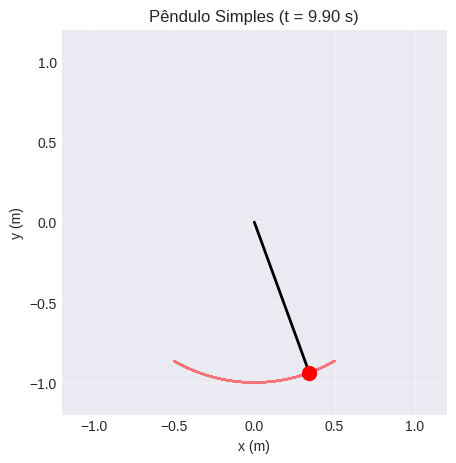

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output
import time

g = 9.81

# ---------------------------
# SIMULAÇÃO
# ---------------------------
def pendulo_simples(theta0, omega0, L, t_max=10, dt=0.02):

    theta = np.radians(theta0)
    omega = omega0

    t_vals = []
    theta_vals = []

    for t in np.arange(0, t_max, dt):

        alpha = -(g / L) * np.sin(theta)

        omega += alpha * dt
        theta += omega * dt

        t_vals.append(t)
        theta_vals.append(theta)

    return np.array(t_vals), np.array(theta_vals)


# ---------------------------
# ANIMAÇÃO
# ---------------------------
def simular(theta0, w0, L):

    t_vals, theta_vals = pendulo_simples(theta0, w0, L)

    x = L * np.sin(theta_vals)
    y = -L * np.cos(theta_vals)

    limite = L * 1.2

    for i in range(0, len(t_vals), 5):

        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(5,5))

        # haste
        ax.plot([0, x[i]], [0, y[i]], 'k-', lw=2)

        # massa
        ax.plot(x[i], y[i], 'ro', markersize=10)

        # trajetória
        ax.plot(x[:i], y[:i], 'r-', alpha=0.5)

        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)

        ax.set_aspect('equal')
        ax.grid(alpha=0.3)

        ax.set_title(f"Pêndulo Simples (t = {t_vals[i]:.2f} s)")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")

        plt.show()

        time.sleep(0.02)


# ---------------------------
# WIDGETS
# ---------------------------
widgets.interact(
    simular,
    theta0=widgets.FloatSlider(min=1, max=170, step=1, value=30, description="θ₀ (°)"),
    w0=widgets.FloatSlider(min=-5, max=5, step=0.5, value=0, description="ω₀ (rad/s)"),
    L=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1, description="L (m)")
);

Pêndulo amortecido (animação)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output
import time

g = 9.81

# ---------------------------
# CLASSIFICAÇÃO DO REGIME
# ---------------------------
def classificar_regime(gamma, L):
    omega0 = np.sqrt(g / L)

    if gamma < 2 * omega0:
        return "Subamortecido (oscilatório)"
    elif np.isclose(gamma, 2 * omega0, atol=0.05):
        return "Criticamente amortecido"
    else:
        return "Superamortecido (não oscila)"


# ---------------------------
# SIMULAÇÃO
# ---------------------------
def pendulo_simples(theta0, omega0, L, gamma, t_max=10, dt=0.02):

    theta = np.radians(theta0)
    omega = omega0

    t_vals = []
    theta_vals = []

    for t in np.arange(0, t_max, dt):

        # EQUAÇÃO COM AMORTECIMENTO
        alpha = -(g / L) * np.sin(theta) - gamma * omega

        omega += alpha * dt
        theta += omega * dt

        t_vals.append(t)
        theta_vals.append(theta)

    return np.array(t_vals), np.array(theta_vals)


# ---------------------------
# ANIMAÇÃO
# ---------------------------
def simular(theta0, w0, L, gamma):

    t_vals, theta_vals = pendulo_simples(theta0, w0, L, gamma)

    x = L * np.sin(theta_vals)
    y = -L * np.cos(theta_vals)

    limite = L * 1.2

    regime = classificar_regime(gamma, L)

    for i in range(0, len(t_vals), 5):

        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(5,5))

        # haste
        ax.plot([0, x[i]], [0, y[i]], 'k-', lw=2)

        # massa
        ax.plot(x[i], y[i], 'ro', markersize=10)

        # trajetória
        ax.plot(x[:i], y[:i], 'r-', alpha=0.5)

        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)

        ax.set_aspect('equal')
        ax.grid(alpha=0.3)

        ax.set_title(
            f"Pêndulo Amortecido\n"
            f"t = {t_vals[i]:.2f} s | γ = {gamma:.2f}\n"
            f"{regime}"
        )

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")

        plt.show()

        time.sleep(0.02)


# ---------------------------
# WIDGETS
# ---------------------------
widgets.interact(
    simular,
    theta0=widgets.FloatSlider(min=1, max=170, step=1, value=30, description="θ₀ (°)"),
    w0=widgets.FloatSlider(min=-5, max=5, step=0.5, value=0, description="ω₀ (rad/s)"),
    L=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1, description="L (m)"),
    gamma=widgets.FloatSlider(min=0, max=5, step=0.1, value=0.5, description="γ")
);

interactive(children=(FloatSlider(value=30.0, description='θ₀ (°)', max=170.0, min=1.0, step=1.0), FloatSlider…

Pêndulo amortecido (gráficos)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

g = 9.81

def simular_pendulo(gamma, L, theta0, modo):

    dt = 0.01
    t_max = 20

    theta = np.radians(theta0)
    omega = 0

    t_vals = []
    theta_vals = []
    omega_vals = []
    alpha_vals = []
    E_vals = []

    for t in np.arange(0, t_max, dt):

        # dinâmica
        alpha = -(g/L)*np.sin(theta) - gamma*omega

        omega += alpha * dt
        theta += omega * dt

        # energia
        E = 0.5*(L**2)*(omega**2) + g*L*(1 - np.cos(theta))

        t_vals.append(t)
        theta_vals.append(theta)
        omega_vals.append(omega)
        alpha_vals.append(alpha)
        E_vals.append(E)

    # -------- regime --------
    omega0 = np.sqrt(g / L)
    gamma_crit = 2 * omega0

    if gamma < gamma_crit:
        regime = "Subamortecido"
    elif np.isclose(gamma, gamma_crit, atol=0.02):
        regime = "Crítico"
    else:
        regime = "Superamortecido"

    # -------- PLOTS --------
    if modo == "Principal":

        fig, axes = plt.subplots(1, 3, figsize=(15,4))

        axes[0].plot(t_vals, theta_vals)
        axes[0].set_title("θ(t) [rad]")
        axes[0].grid()

        axes[1].plot(t_vals, omega_vals)
        axes[1].set_title("ω(t) [rad/s]")
        axes[1].grid()

        axes[2].plot(t_vals, E_vals)
        axes[2].set_title("Energia")
        axes[2].grid()

    elif modo == "Análise":

        fig, axes = plt.subplots(1, 3, figsize=(15,4))

        # espaço de fase
        axes[0].plot(theta_vals, omega_vals)
        axes[0].set_title("Fase (ω vs θ)")
        axes[0].grid()

        # aceleração angular
        axes[1].plot(t_vals, alpha_vals)
        axes[1].set_title("α(t) [rad/s²]")
        axes[1].grid()

        # θ(t) para referência
        axes[2].plot(t_vals, theta_vals)
        axes[2].set_title("θ(t)")
        axes[2].grid()

    plt.suptitle(f"Pêndulo Amortecido | {regime}")
    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)

    if modo == "Principal":
        print("Visualização padrão do sistema.")
        print("Mostra posição angular, velocidade e energia.")
        print("A energia decai devido ao amortecimento.")

    elif modo == "Análise":
        print("Modo de análise dinâmica.")
        print("Espaço de fase mostra convergência ao equilíbrio.")
        print("A aceleração depende de posição e velocidade.")


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    simular_pendulo,
    gamma=widgets.FloatSlider(min=0, max=5, step=0.1, value=0.5, description="γ"),
    L=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1, description="L (m)"),
    theta0=widgets.FloatSlider(min=1, max=90, step=1, value=30, description="θ₀ (°)"),
    modo=widgets.Dropdown(
        options=["Principal", "Análise"],
        value="Principal",
        description="Modo"
    )
);

interactive(children=(FloatSlider(value=0.5, description='γ', max=5.0), FloatSlider(value=1.0, description='L …

RLC (gráficos)

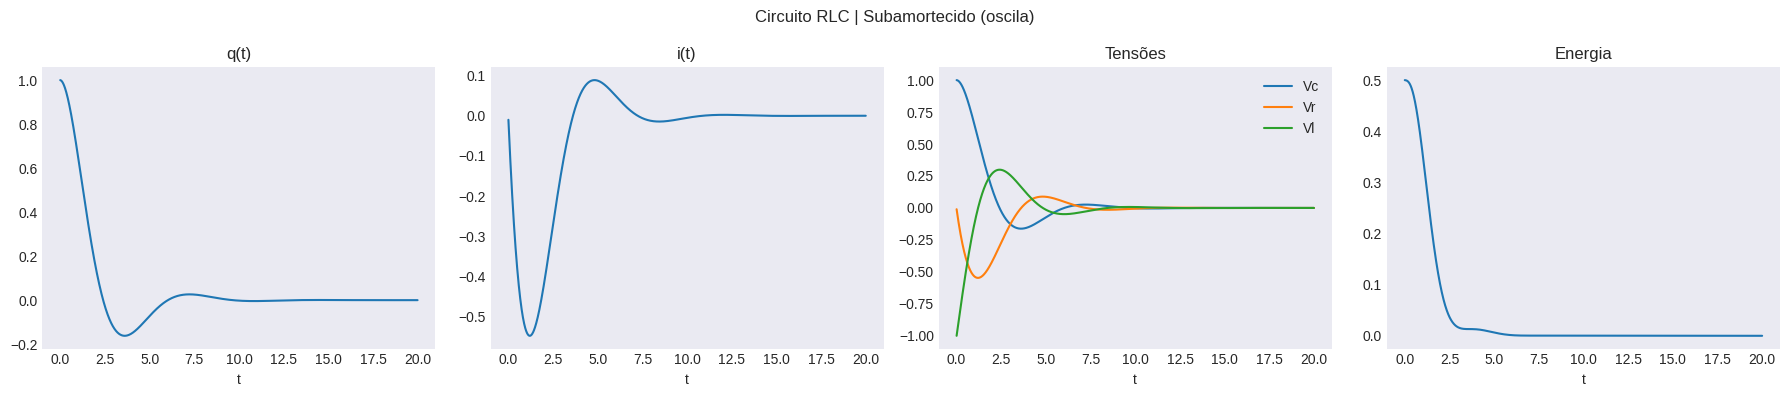


👀 Perguntas:
- Corrente e carga estão em fase?
- O que acontece com as tensões ao longo do tempo?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def simular_rlc(R, L, C, q0, slide, mostrar_resposta):

    dt = 0.01
    t_max = 20

    q = q0
    i = 0

    t_vals = []
    q_vals = []
    i_vals = []
    vc_vals = []
    vr_vals = []
    vl_vals = []
    E_vals = []

    for t in np.arange(0, t_max, dt):

        a = -(R/L)*i - (1/(L*C))*q

        i += a * dt
        q += i * dt

        vc = q / C
        vr = R * i
        vl = L * a

        E = (q**2)/(2*C) + 0.5*L*i**2

        t_vals.append(t)
        q_vals.append(q)
        i_vals.append(i)
        vc_vals.append(vc)
        vr_vals.append(vr)
        vl_vals.append(vl)
        E_vals.append(E)

    # -------- regime --------
    gamma = R/(2*L)
    omega0 = np.sqrt(1/(L*C))

    if gamma < omega0:
        regime = "Subamortecido (oscila)"
    elif abs(gamma - omega0) < 1e-3:
        regime = "Criticamente amortecido"
    else:
        regime = "Superamortecido (não oscila)"

    # -------- PLOTS (LAYOUT NOVO) --------
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18,4))

    # carga
    ax1.plot(t_vals, q_vals)
    ax1.set_title("q(t)")
    ax1.set_xlabel("t")
    ax1.grid()

    # corrente
    ax2.plot(t_vals, i_vals)
    ax2.set_title("i(t)")
    ax2.set_xlabel("t")
    ax2.grid()

    # tensões
    ax3.plot(t_vals, vc_vals, label="Vc")
    ax3.plot(t_vals, vr_vals, label="Vr")
    ax3.plot(t_vals, vl_vals, label="Vl")
    ax3.set_title("Tensões")
    ax3.legend()
    ax3.set_xlabel("t")
    ax3.grid()

    # energia
    ax4.plot(t_vals, E_vals)
    ax4.set_title("Energia")
    ax4.set_xlabel("t")
    ax4.grid()

    plt.suptitle(f"Circuito RLC | {regime}")
    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)

    # =====================================================
    # PERGUNTAS (inalteradas)
    # =====================================================

    if slide == "Explorar":
        print("👀 Perguntas:")
        print("- Corrente e carga estão em fase?")
        print("- O que acontece com as tensões ao longo do tempo?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Não. A corrente depende da derivada da carga.")
            print("- Todas decaem devido à dissipação no resistor.")

    elif slide == "Corrente vs carga":
        print("⚡ Perguntas:")
        print("- Quando a corrente é máxima?")
        print("- Quando a carga é máxima?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Corrente máxima quando a carga cruza zero.")
            print("- Carga máxima nos extremos.")

    elif slide == "Tensões":
        print("🔌 Perguntas:")
        print("- As tensões somam zero?")
        print("- Qual elemento domina em diferentes momentos?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Sim: V_L + V_R + V_C = 0.")
            print("- Depende do instante.")

    elif slide == "Energia":
        print("🔥 Perguntas:")
        print("- A energia total se conserva?")
        print("- Por que ela diminui?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Não, devido ao resistor.")
            print("- Dissipação em calor.")

    elif slide == "Regimes":
        print("⚖️ Perguntas:")
        print("- Como o comportamento muda com R?")
        print("- Quando há oscilação?")

        if mostrar_resposta:
            print("\n✅ Respostas:")
            print("- Maior R → menos oscilação.")
            print("- Só no subamortecido.")

# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    simular_rlc,
    R=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1),
    L=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1),
    C=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1),
    q0=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1),
    slide=widgets.Dropdown(
        options=[
            "Explorar",
            "Corrente vs carga",
            "Tensões",
            "Energia",
            "Regimes"
        ]
    ),
    mostrar_resposta=widgets.Checkbox(value=False)
);

RLC (animação)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output
import time

def simular(R, L, C, q0):

    dt = 0.02  # s
    t_max = 20  # s

    q = q0      # C
    i = 0       # A

    t_vals = []
    i_vals = []

    for t in np.arange(0, t_max, dt):

        a = -(R/L)*i - (1/(L*C))*q  # A/s

        i += a * dt
        q += i * dt

        t_vals.append(t)
        i_vals.append(i)

    t_vals = np.array(t_vals)
    i_vals = np.array(i_vals)

    # circuito
    width = 6
    height = 3
    perimeter = 2*(width + height)

    N = 40
    s = np.linspace(0, perimeter, N)

    def pos(s):
        s = s % perimeter

        if s < width:
            return s, 0
        elif s < width + height:
            return width, s - width
        elif s < 2*width + height:
            return width - (s - (width + height)), height
        else:
            return 0, height - (s - (2*width + height))

    # ---------------------------
    # LOOP
    # ---------------------------
    for k in range(0, len(t_vals), 2):

        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

        v = i_vals[k]

        # suavização
        if abs(v) < 0.02:
            vel = 0
        else:
            vel = np.tanh(v)

        s += vel * dt * 3
        s = np.mod(s, perimeter)

        xs, ys = [], []
        for si in s:
            x, y = pos(si)
            xs.append(x)
            ys.append(y)

        # =========================
        # CIRCUITO
        # =========================
        ax1.plot([0,width],[0,0],'k',lw=2)
        ax1.plot([width,width],[0,height],'k',lw=2)
        ax1.plot([width,0],[height,height],'k',lw=2)
        ax1.plot([0,0],[height,0],'k',lw=2)

        # resistor
        x_r = np.linspace(1, 2.5, 10)
        y_r = 0.2*np.sin(np.linspace(0, 6*np.pi, 10))
        ax1.plot(x_r, y_r, 'k', lw=2)

        # capacitor
        ax1.plot([3.5,3.5],[height-0.5,height+0.5],'k',lw=3)
        ax1.plot([4,4],[height-0.5,height+0.5],'k',lw=3)

        # indutor
        theta = np.linspace(0, 2*np.pi, 100)
        for n in range(5):
            xL = width + 0.4*np.cos(theta)
            yL = 0.5 + n*0.4 + 0.4*np.sin(theta)
            ax1.plot(xL, yL, 'k')

        # elétrons
        color = 'blue' if v > 0 else 'red'
        ax1.scatter(xs, ys, s=40, c=color)

        # seta
        ax1.arrow(width/2, -0.5, np.sign(v)*1.0, 0,
                  head_width=0.2, length_includes_head=True)

        ax1.set_xlim(-1, width+2)
        ax1.set_ylim(-1, height+2)
        ax1.set_title("Circuito RLC")
        ax1.axis('off')

        # =========================
        # GRÁFICO
        # =========================
        ax2.plot(t_vals[:k], i_vals[:k])
        ax2.axvline(t_vals[k], linestyle='--')

        ax2.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Corrente i(t) (A)")
        ax2.set_title("Corrente no circuito")
        ax2.grid()

        ax2.set_xlim(0, t_max)
        ax2.set_ylim(min(i_vals)*1.2, max(i_vals)*1.2)

        # título geral com unidades
        plt.suptitle(
            f"R = {R:.2f} Ω | L = {L:.2f} H | C = {C:.2f} F | q₀ = {q0:.2f} C\n"
            f"i(t) = {v:.3f} A  |  t = {t_vals[k]:.2f} s"
        )

        plt.tight_layout()
        plt.show()

        time.sleep(0.03)


# ---------------------------
# INTERFACE (COM UNIDADES)
# ---------------------------
widgets.interact(
    simular,
    R=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description="R (Ω)"),
    L=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="L (H)"),
    C=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="C (F)"),
    q0=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="q0 (C)")
);

interactive(children=(FloatSlider(value=1.0, description='R (Ω)', max=10.0, min=0.1), FloatSlider(value=1.0, d…

RLC

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def simular_frame(R, L, C, q0, frame):

    dt = 0.02
    t_max = 20

    q = q0
    i = 0

    t_vals = []
    i_vals = []

    for t in np.arange(0, t_max, dt):
        a = -(R/L)*i - (1/(L*C))*q
        i += a * dt
        q += i * dt

        t_vals.append(t)
        i_vals.append(i)

    t_vals = np.array(t_vals)
    i_vals = np.array(i_vals)

    frame = min(frame, len(t_vals)-1)

    # circuito
    width = 6
    height = 3
    perimeter = 2*(width + height)

    N = 40
    s = np.linspace(0, perimeter, N)

    def pos(s):
        s = s % perimeter

        if s < width:
            return s, 0
        elif s < width + height:
            return width, s - width
        elif s < 2*width + height:
            return width - (s - (width + height)), height
        else:
            return 0, height - (s - (2*width + height))

    v = i_vals[frame]

    # movimento proporcional ao tempo
    s += np.tanh(v) * dt * frame
    s = np.mod(s, perimeter)

    xs, ys = [], []
    for si in s:
        x, y = pos(si)
        xs.append(x)
        ys.append(y)

    # ---------------------------
    # PLOT
    # ---------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    # circuito
    ax1.plot([0,width],[0,0],'k',lw=2)
    ax1.plot([width,width],[0,height],'k',lw=2)
    ax1.plot([width,0],[height,height],'k',lw=2)
    ax1.plot([0,0],[height,0],'k',lw=2)

    x_r = np.linspace(1, 2.5, 10)
    y_r = 0.2*np.sin(np.linspace(0, 6*np.pi, 10))
    ax1.plot(x_r, y_r, 'k', lw=2)

    ax1.plot([3.5,3.5],[height-0.5,height+0.5],'k',lw=3)
    ax1.plot([4,4],[height-0.5,height+0.5],'k',lw=3)

    theta = np.linspace(0, 2*np.pi, 100)
    for n in range(5):
        xL = width + 0.4*np.cos(theta)
        yL = 0.5 + n*0.4 + 0.4*np.sin(theta)
        ax1.plot(xL, yL, 'k')

    color = 'blue' if v > 0 else 'red'
    ax1.scatter(xs, ys, s=40, c=color)

    ax1.set_xlim(-1, width+2)
    ax1.set_ylim(-1, height+2)
    ax1.set_title("Circuito RLC")
    ax1.axis('off')

    # gráfico
    ax2.plot(t_vals, i_vals)
    ax2.axvline(t_vals[frame], linestyle='--')

    ax2.set_xlabel("Tempo (s)")
    ax2.set_ylabel("Corrente (A)")
    ax2.grid()

    plt.suptitle(
        f"t = {t_vals[frame]:.2f} s | i = {v:.3f} A"
    )

    plt.tight_layout()
    plt.show()


# ---------------------------
# CONTROLES
# ---------------------------
widgets.interact(
    simular_frame,
    R=widgets.FloatSlider(0.1, 10, 0.1, value=1, description="R (Ω)"),
    L=widgets.FloatSlider(0.1, 5, 0.1, value=1, description="L (H)"),
    C=widgets.FloatSlider(0.1, 5, 0.1, value=1, description="C (F)"),
    q0=widgets.FloatSlider(0.1, 5, 0.1, value=1, description="q₀ (C)"),
    frame=widgets.IntSlider(min=0, max=500, step=1, value=0, description="tempo")
);

TypeError: _Float.__init__() got multiple values for argument 'value'

Pêndulo duplo

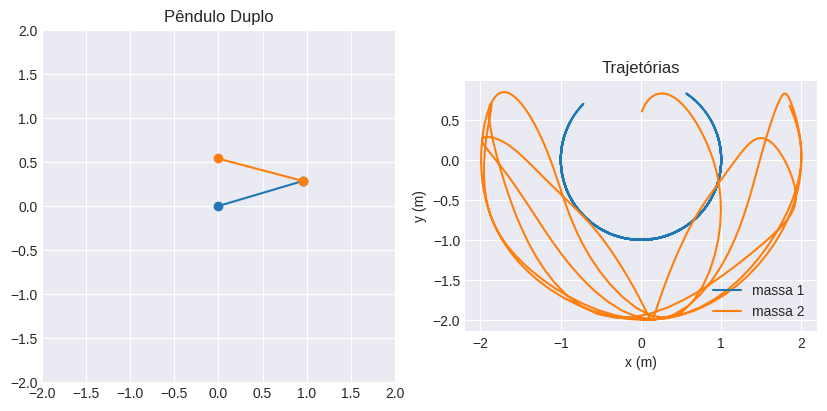

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.integrate import solve_ivp
from IPython.display import clear_output
import time

g = 9.81

# ---------------------------
# EDO
# ---------------------------
def pendulo_duplo(t, y, m1, m2, L1, L2):
    theta1, w1, theta2, w2 = y

    delta = theta2 - theta1

    den1 = (m1 + m2)*L1 - m2*L1*np.cos(delta)**2

    a1 = (
        m2*L1*w1**2*np.sin(delta)*np.cos(delta)
        + m2*g*np.sin(theta2)*np.cos(delta)
        + m2*L2*w2**2*np.sin(delta)
        - (m1 + m2)*g*np.sin(theta1)
    ) / den1

    den2 = (L2/L1)*den1

    a2 = (
        -m2*L2*w2**2*np.sin(delta)*np.cos(delta)
        + (m1 + m2)*g*np.sin(theta1)*np.cos(delta)
        - (m1 + m2)*L1*w1**2*np.sin(delta)
        - (m1 + m2)*g*np.sin(theta2)
    ) / den2

    return [w1, a1, w2, a2]


# ---------------------------
# SIMULAÇÃO (SEM DIDÁTICA)
# ---------------------------
def simular(theta1, theta2, w1, w2, m1, m2, L1, L2):

    y0 = [np.radians(theta1), w1, np.radians(theta2), w2]

    t_span = (0, 10)
    t_eval = np.linspace(0, 10, 400)

    sol = solve_ivp(
        pendulo_duplo,
        t_span,
        y0,
        t_eval=t_eval,
        args=(m1, m2, L1, L2),
        method='RK45'
    )

    theta1 = sol.y[0]
    theta2 = sol.y[2]

    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)

    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)

    for i in range(0, len(t_eval), 10):  # 🔥 mais leve
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

        ax1.plot([0, x1[i]], [0, y1[i]], 'o-')
        ax1.plot([x1[i], x2[i]], [y1[i], y2[i]], 'o-')
        ax1.set_xlim(-2, 2)
        ax1.set_ylim(-2, 2)
        ax1.set_title("Pêndulo Duplo")
        ax1.set_aspect('equal')

        ax2.plot(x1[:i], y1[:i], label="massa 1")
        ax2.plot(x2[:i], y2[:i], label="massa 2")
        ax2.set_title("Trajetórias")
        ax2.set_xlabel("x (m)")
        ax2.set_ylabel("y (m)")
        ax2.legend()
        ax2.set_aspect('equal')

        plt.show()
        time.sleep(0.03)


widgets.interact(
    simular,
    theta1=widgets.FloatSlider(min=0, max=180, step=5, value=120),
    theta2=widgets.FloatSlider(min=0, max=180, step=5, value=100),
    w1=widgets.FloatSlider(min=-5, max=5, step=0.5, value=0),
    w2=widgets.FloatSlider(min=-5, max=5, step=0.5, value=0),
    m1=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1),
    m2=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1),
    L1=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1),
    L2=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1),
);

Pêndulo duplo 2.0




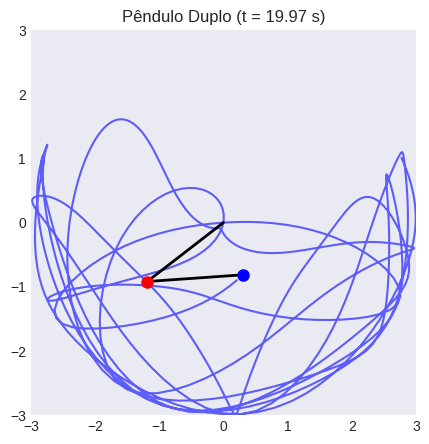

<function __main__.simular(theta1_0, theta2_0, m1, m2, L1, L2)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.integrate import solve_ivp
from IPython.display import clear_output
import time

g = 9.81

# ---------------------------
# EDO DO PÊNDULO DUPLO
# ---------------------------
def pendulo_duplo(t, y, m1, m2, L1, L2):
    theta1, z1, theta2, z2 = y  # z = dθ/dt

    delta = theta2 - theta1

    den1 = (m1 + m2)*L1 - m2*L1*np.cos(delta)**2
    den2 = (L2/L1)*den1

    dtheta1 = z1
    dtheta2 = z2

    dz1 = (
        m2*L1*z1**2*np.sin(delta)*np.cos(delta)
        + m2*g*np.sin(theta2)*np.cos(delta)
        + m2*L2*z2**2*np.sin(delta)
        - (m1 + m2)*g*np.sin(theta1)
    ) / den1

    dz2 = (
        -m2*L2*z2**2*np.sin(delta)*np.cos(delta)
        + (m1 + m2)*g*np.sin(theta1)*np.cos(delta)
        - (m1 + m2)*L1*z1**2*np.sin(delta)
        - (m1 + m2)*g*np.sin(theta2)
    ) / den2

    return [dtheta1, dz1, dtheta2, dz2]


# ---------------------------
# SIMULAÇÃO (ESTILO IGUAL AO SEU)
# ---------------------------
def simular(theta1_0, theta2_0, m1, m2, L1, L2):

    # condições iniciais
    y0 = [
        np.radians(theta1_0),  # θ1
        0.0,                   # ω1
        np.radians(theta2_0),  # θ2
        0.0                    # ω2
    ]

    t_eval = np.linspace(0, 20, 800)

    sol = solve_ivp(
        pendulo_duplo,
        (0, 20),
        y0,
        t_eval=t_eval,
        args=(m1, m2, L1, L2)
    )

    theta1 = sol.y[0]
    theta2 = sol.y[2]

    # posições
    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)

    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)

    # ---------------------------
    # LOOP DE ANIMAÇÃO
    # ---------------------------
    for i in range(0, len(t_eval), 3):

        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(5,5))

        # trajetória da massa 2 (caos bonito 😈)
        ax.plot(x2[:i], y2[:i], 'b-', alpha=0.6)

        # hastes
        ax.plot([0, x1[i]], [0, y1[i]], 'k-', lw=2)
        ax.plot([x1[i], x2[i]], [y1[i], y2[i]], 'k-', lw=2)

        # massas
        ax.plot(x1[i], y1[i], 'ro', markersize=8)
        ax.plot(x2[i], y2[i], 'bo', markersize=8)

        # limites
        limite = L1 + L2
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)

        ax.set_aspect('equal')

        ax.set_title(f"Pêndulo Duplo (t = {t_eval[i]:.2f} s)")

        plt.grid()
        plt.show()

        time.sleep(0.03)


# ---------------------------
# WIDGETS
# ---------------------------
widgets.interact(
    simular,
    theta1_0=widgets.FloatSlider(min=0, max=180, step=1, value=120, description="θ1 (°)"),
    theta2_0=widgets.FloatSlider(min=0, max=180, step=1, value=100, description="θ2 (°)"),
    m1=widgets.FloatSlider(min=0.5, max=5, step=0.1, value=1, description="m1 (kg)"),
    m2=widgets.FloatSlider(min=0.5, max=5, step=0.1, value=1, description="m2 (kg)"),
    L1=widgets.FloatSlider(min=0.5, max=3, step=0.1, value=1.5, description="L1 (m)"),
    L2=widgets.FloatSlider(min=0.5, max=3, step=0.1, value=1.5, description="L2 (m)")
)

Pêndulo duplo 3.0

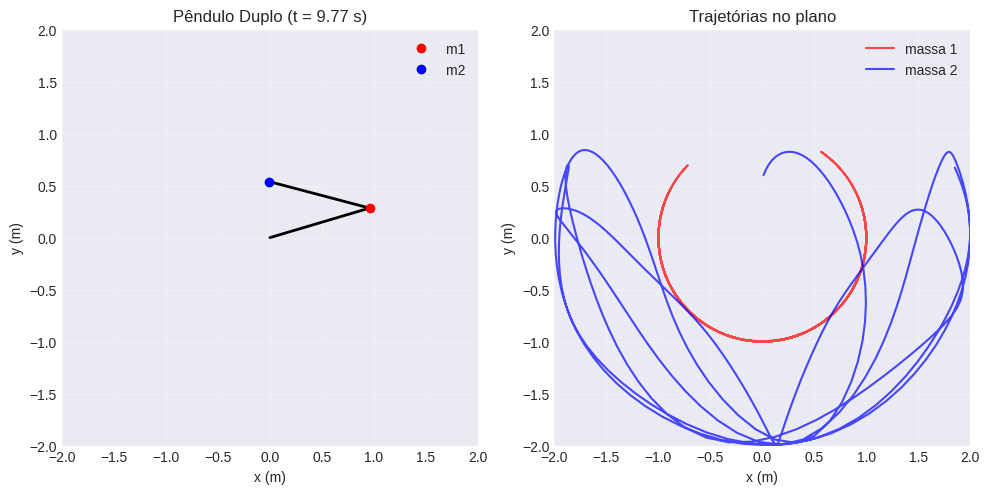

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.integrate import solve_ivp
from IPython.display import clear_output
import time

g = 9.81  # m/s²

# ---------------------------
# EDO
# ---------------------------
def pendulo_duplo(t, y, m1, m2, L1, L2):
    theta1, w1, theta2, w2 = y

    delta = theta2 - theta1

    den1 = (m1 + m2)*L1 - m2*L1*np.cos(delta)**2

    a1 = (
        m2*L1*w1**2*np.sin(delta)*np.cos(delta)
        + m2*g*np.sin(theta2)*np.cos(delta)
        + m2*L2*w2**2*np.sin(delta)
        - (m1 + m2)*g*np.sin(theta1)
    ) / den1

    den2 = (L2/L1)*den1

    a2 = (
        -m2*L2*w2**2*np.sin(delta)*np.cos(delta)
        + (m1 + m2)*g*np.sin(theta1)*np.cos(delta)
        - (m1 + m2)*L1*w1**2*np.sin(delta)
        - (m1 + m2)*g*np.sin(theta2)
    ) / den2

    return [w1, a1, w2, a2]


# ---------------------------
# SIMULAÇÃO
# ---------------------------
def simular(theta1, theta2, w1, w2, m1, m2, L1, L2):

    y0 = [np.radians(theta1), w1, np.radians(theta2), w2]

    t_span = (0, 10)
    t_eval = np.linspace(0, 10, 400)

    sol = solve_ivp(
        pendulo_duplo,
        t_span,
        y0,
        t_eval=t_eval,
        args=(m1, m2, L1, L2),
        method='RK45'
    )

    theta1 = sol.y[0]
    theta2 = sol.y[2]

    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)

    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)

    limite = L1 + L2

    for i in range(0, len(t_eval), 10):
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

        # ---------------------------
        # PÊNDULO
        # ---------------------------
        ax1.plot([0, x1[i]], [0, y1[i]], 'k-', lw=2)
        ax1.plot([x1[i], x2[i]], [y1[i], y2[i]], 'k-', lw=2)

        ax1.plot(x1[i], y1[i], 'ro', label="m1")
        ax1.plot(x2[i], y2[i], 'bo', label="m2")

        ax1.set_xlim(-limite, limite)
        ax1.set_ylim(-limite, limite)

        ax1.set_title(f"Pêndulo Duplo (t = {t_eval[i]:.2f} s)")
        ax1.set_xlabel("x (m)")
        ax1.set_ylabel("y (m)")
        ax1.set_aspect('equal')
        ax1.grid(alpha=0.3)
        ax1.legend()

        # ---------------------------
        # TRAJETÓRIA
        # ---------------------------
        ax2.plot(x1[:i], y1[:i], 'r-', alpha=0.7, label="massa 1")
        ax2.plot(x2[:i], y2[:i], 'b-', alpha=0.7, label="massa 2")

        ax2.set_xlim(-limite, limite)
        ax2.set_ylim(-limite, limite)

        ax2.set_title("Trajetórias no plano")
        ax2.set_xlabel("x (m)")
        ax2.set_ylabel("y (m)")
        ax2.set_aspect('equal')
        ax2.grid(alpha=0.3)
        ax2.legend()

        plt.tight_layout()
        plt.show()

        time.sleep(0.03)


# ---------------------------
# WIDGETS
# ---------------------------
widgets.interact(
    simular,
    theta1=widgets.FloatSlider(min=0, max=180, step=5, value=120, description="θ1 (°)"),
    theta2=widgets.FloatSlider(min=0, max=180, step=5, value=100, description="θ2 (°)"),
    w1=widgets.FloatSlider(min=-5, max=5, step=0.5, value=0, description="ω1 (rad/s)"),
    w2=widgets.FloatSlider(min=-5, max=5, step=0.5, value=0, description="ω2 (rad/s)"),
    m1=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1, description="m1 (kg)"),
    m2=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1, description="m2 (kg)"),
    L1=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1, description="L1 (m)"),
    L2=widgets.FloatSlider(min=0.5, max=2, step=0.1, value=1, description="L2 (m)"),
);

Oscilador acoplado com 2 massas

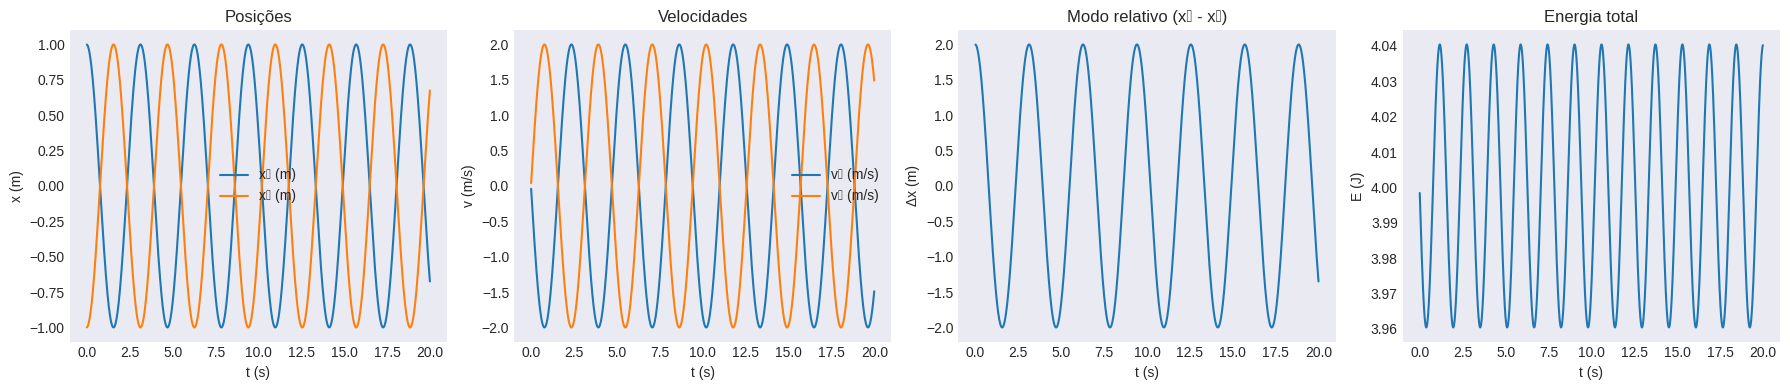


🔬 Sistema: Osciladores acoplados
Modo identificado: Modo antissimétrico (opostas)

👀 Perguntas:
- O que acontece quando kc aumenta?
- Quando aparece batimento?
- Como identificar modos normais?


<function __main__.simular_acoplados(m, k, kc, x1_0, x2_0, v1_0, v2_0)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def simular_acoplados(m, k, kc, x1_0, x2_0, v1_0, v2_0):

    dt = 0.01
    t_max = 20
    t = np.arange(0, t_max, dt)

    x1, x2 = x1_0, x2_0
    v1, v2 = v1_0, v2_0

    x1_vals, x2_vals = [], []
    v1_vals, v2_vals = [], []
    E_vals = []

    for _ in t:

        # acelerações (SI)
        a1 = (-k*x1 + kc*(x2 - x1)) / m
        a2 = (-k*x2 + kc*(x1 - x2)) / m

        # atualização
        v1 += a1 * dt
        v2 += a2 * dt
        x1 += v1 * dt
        x2 += v2 * dt

        # energia (SI)
        Ec = 0.5*m*(v1**2 + v2**2)
        Ep = 0.5*k*(x1**2 + x2**2) + 0.5*kc*(x2 - x1)**2
        E = Ec + Ep

        # salvar
        x1_vals.append(x1)
        x2_vals.append(x2)
        v1_vals.append(v1)
        v2_vals.append(v2)
        E_vals.append(E)

    # -------- DETECÇÃO DE MODO --------
    if abs(x1_0 - x2_0) < 1e-2:
        modo = "Modo simétrico (massas juntas)"
    elif abs(x1_0 + x2_0) < 1e-2:
        modo = "Modo antissimétrico (opostas)"
    else:
        modo = "Mistura de modos (batimentos)"

    # -------- PLOTS (PADRÃO APP) --------
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18,4))

    # posições
    ax1.plot(t, x1_vals, label="x₁ (m)")
    ax1.plot(t, x2_vals, label="x₂ (m)")
    ax1.set_title("Posições")
    ax1.set_xlabel("t (s)")
    ax1.set_ylabel("x (m)")
    ax1.legend()
    ax1.grid()

    # velocidades
    ax2.plot(t, v1_vals, label="v₁ (m/s)")
    ax2.plot(t, v2_vals, label="v₂ (m/s)")
    ax2.set_title("Velocidades")
    ax2.set_xlabel("t (s)")
    ax2.set_ylabel("v (m/s)")
    ax2.legend()
    ax2.grid()

    # modo relativo
    ax3.plot(t, np.array(x1_vals) - np.array(x2_vals))
    ax3.set_title("Modo relativo (x₁ - x₂)")
    ax3.set_xlabel("t (s)")
    ax3.set_ylabel("Δx (m)")
    ax3.grid()

    # energia
    ax4.plot(t, E_vals)
    ax4.set_title("Energia total")
    ax4.set_xlabel("t (s)")
    ax4.set_ylabel("E (J)")
    ax4.grid()

    plt.tight_layout()
    plt.show()

    # -------- OUTPUT DIDÁTICO --------
    print("\n" + "="*50)
    print("🔬 Sistema: Osciladores acoplados")
    print(f"Modo identificado: {modo}")

    print("\n👀 Perguntas:")
    print("- O que acontece quando kc aumenta?")
    print("- Quando aparece batimento?")
    print("- Como identificar modos normais?")

# -------- INTERFACE --------
interact(
    simular_acoplados,
    m=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1, description="m (kg)"),
    k=widgets.FloatSlider(min=0.5, max=10, step=0.5, value=2, description="k (N/m)"),
    kc=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description="k_c (N/m)"),
    x1_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1, description="x₁₀ (m)"),
    x2_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=-1, description="x₂₀ (m)"),
    v1_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0, description="v₁₀ (m/s)"),
    v2_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0, description="v₂₀ (m/s)")
)

Oscilador acoplado animado

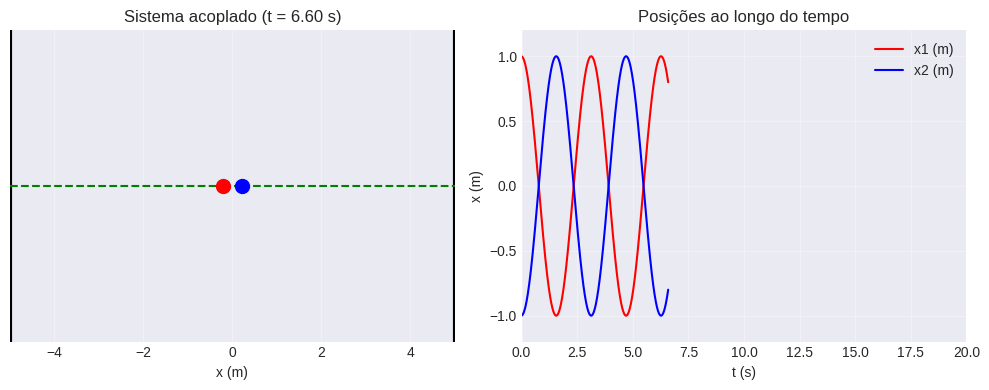

Modo: Modo antissimétrico


KeyboardInterrupt: 

<function __main__.simular_acoplados(m, k, kc, x1_0, x2_0, v1_0, v2_0)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import clear_output
import time

def simular_acoplados(m, k, kc, x1_0, x2_0, v1_0, v2_0):

    dt = 0.01
    t_max = 20
    t = np.arange(0, t_max, dt)

    x1, x2 = x1_0, x2_0
    v1, v2 = v1_0, v2_0

    x1_vals, x2_vals = [], []
    E_vals = []

    # ---------------------------
    # SIMULAÇÃO
    # ---------------------------
    for _ in t:

        a1 = (-k*x1 + kc*(x2 - x1)) / m
        a2 = (-k*x2 + kc*(x1 - x2)) / m

        v1 += a1 * dt
        v2 += a2 * dt
        x1 += v1 * dt
        x2 += v2 * dt

        Ec = 0.5*m*(v1**2 + v2**2)
        Ep = 0.5*k*(x1**2 + x2**2) + 0.5*kc*(x2 - x1)**2
        E = Ec + Ep

        x1_vals.append(x1)
        x2_vals.append(x2)
        E_vals.append(E)

    # -------- DETECÇÃO DE MODO --------
    if abs(x1_0 - x2_0) < 1e-2:
        modo = "Modo simétrico"
    elif abs(x1_0 + x2_0) < 1e-2:
        modo = "Modo antissimétrico"
    else:
        modo = "Batimento"

    # ---------------------------
    # ANIMAÇÃO
    # ---------------------------
    L = 5  # posição das paredes

    for i in range(0, len(t), 10):
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

        # ---------------------------
        # SISTEMA FÍSICO
        # ---------------------------
        # paredes
        ax1.plot([-L, -L], [-1, 1], 'k', lw=3)
        ax1.plot([L, L], [-1, 1], 'k', lw=3)

        # massas (posições no eixo x)
        X1 = -1 + x1_vals[i]
        X2 =  1 + x2_vals[i]

        # molas (linhas simples)
        ax1.plot([-L, X1], [0, 0], 'g--')
        ax1.plot([X1, X2], [0, 0], 'g--')
        ax1.plot([X2, L], [0, 0], 'g--')

        # massas
        ax1.plot(X1, 0, 'ro', markersize=10)
        ax1.plot(X2, 0, 'bo', markersize=10)

        ax1.set_xlim(-L, L)
        ax1.set_ylim(-1, 1)
        ax1.set_title(f"Sistema acoplado (t = {t[i]:.2f} s)")
        ax1.set_xlabel("x (m)")
        ax1.set_yticks([])
        ax1.grid(alpha=0.3)

        # ---------------------------
        # GRÁFICO DINÂMICO
        # ---------------------------
        ax2.plot(t[:i], x1_vals[:i], 'r-', label="x1 (m)")
        ax2.plot(t[:i], x2_vals[:i], 'b-', label="x2 (m)")

        ax2.set_xlim(0, t_max)
        ax2.set_ylim(
            1.2*min(min(x1_vals), min(x2_vals)),
            1.2*max(max(x1_vals), max(x2_vals))
        )

        ax2.set_title("Posições ao longo do tempo")
        ax2.set_xlabel("t (s)")
        ax2.set_ylabel("x (m)")
        ax2.legend()
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Modo: {modo}")

        time.sleep(0.03)


# ---------------------------
# INTERFACE
# ---------------------------
interact(
    simular_acoplados,
    m=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1, description="m (kg)"),
    k=widgets.FloatSlider(min=0.5, max=10, step=0.5, value=2, description="k (N/m)"),
    kc=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description="k_c (N/m)"),
    x1_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=1, description="x1 (m)"),
    x2_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=-1, description="x2 (m)"),
    v1_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0, description="v1 (m/s)"),
    v2_0=widgets.FloatSlider(min=-2, max=2, step=0.1, value=0, description="v1 (m/s)")
)

Lançamento oblíquo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy.integrate import solve_ivp
from IPython.display import clear_output
import time

g = 9.81  # m/s²

# ---------------------------
# EDO (COM ARRASTO)
# ---------------------------
def projeteis(t, y, m, c):
    x, y_pos, vx, vy = y

    v = np.sqrt(vx**2 + vy**2)

    dvx = -(c/m) * v * vx
    dvy = -g - (c/m) * v * vy

    return [vx, vy, dvx, dvy]


# ---------------------------
# SIMULAÇÃO (MESMO ESTILO)
# ---------------------------
def simular(v0, angulo, m, c):

    theta = np.radians(angulo)

    # condição inicial (SI)
    y0 = [
        0.0,                    # x (m)
        0.0,                    # y (m)
        v0*np.cos(theta),       # vx (m/s)
        v0*np.sin(theta)        # vy (m/s)
    ]

    t_eval = np.linspace(0, 5, 200)

    sol = solve_ivp(
        projeteis,
        (0, 5),
        y0,
        t_eval=t_eval,
        args=(m, c)
    )

    x = sol.y[0]
    y_pos = sol.y[1]

    # corta quando bate no chão
    valid = y_pos >= 0
    x = x[valid]
    y_pos = y_pos[valid]
    t_plot = t_eval[:len(x)]

    # ---------------------------
    # LOOP (IGUAL AO SEU)
    # ---------------------------
    for i in range(0, len(x), 3):

        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(6,4))

        # trajetória
        ax.plot(x[:i], y_pos[:i], 'b-')

        # projétil
        ax.plot(x[i], y_pos[i], 'ro')

        ax.set_xlim(0, max(x)*1.1 if len(x)>0 else 1)
        ax.set_ylim(0, max(y_pos)*1.1 if len(y_pos)>0 else 1)

        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        ax.set_title(f"Projétil com Arrasto (t = {t_plot[i]:.2f} s)")

        plt.show()

        time.sleep(0.03)


# ---------------------------
# WIDGET
# ---------------------------
widgets.interact(
    simular,
    v0=widgets.FloatSlider(min=5, max=50, step=1, value=20, description="v0 (m/s)"),
    angulo=widgets.FloatSlider(min=10, max=80, step=1, value=45, description="θ (°)"),
    m=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="m (kg)"),
    c=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.1, description="c (kg/m)")
)

Planck

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output
import time

# =========================
# CONSTANTES (SI)
# =========================
h = 6.626e-34      # J·s
c = 3e8            # m/s
k = 1.38e-23       # J/K

# =========================
# PLANCK (frequência)
# =========================
def planck(nu, T):
    return (2*h*nu**3 / c**2) / (np.exp(h*nu/(k*T)) - 1)

# =========================
# SIMULAÇÃO
# =========================
def simular(T_min, T_max):

    nu = np.linspace(1e12, 3e15, 400)  # Hz
    temps = np.linspace(T_min, T_max, 80)

    for i in range(0, len(temps), 2):

        clear_output(wait=True)

        T = temps[i]
        B = planck(nu, T)

        plt.figure(figsize=(6,4))

        plt.plot(nu, B)

        plt.xlabel("Frequência ν (Hz)")
        plt.ylabel("B(ν,T) (W·sr⁻¹·m⁻²·Hz⁻¹)")
        plt.title(f"Radiação de Corpo Negro (T = {T:.0f} K)")

        plt.xlim(nu[0], nu[-1])
        plt.ylim(0, np.max(B)*1.1)

        plt.grid()

        plt.show()

        time.sleep(0.05)


# =========================
# WIDGET
# =========================
widgets.interact(
    simular,
    T_min=widgets.FloatSlider(min=500, max=3000, step=100, value=1000, description="T min (K)"),
    T_max=widgets.FloatSlider(min=2000, max=10000, step=200, value=6000, description="T max (K)")
)

Mudança de estado físico (Versão final)

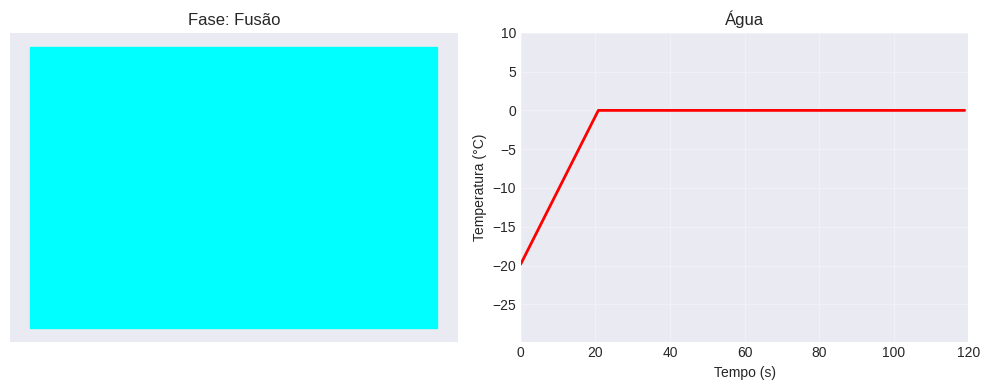

Material: Água
Tempo = 119.2 s
Temperatura = 0.0 °C
Fase = Fusão


<function __main__.simular(material, m, T0, potencia)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output

# =========================
# BANCO DE MATERIAIS
# =========================
materiais = {
    "Água": {
        "Tf": 0,
        "Tb": 100,
        "c_s": 2100,
        "c_l": 4186,
        "c_g": 2000,
        "Lf": 3.34e5,
        "Lv": 2.26e6
    },
    "Etanol": {
        "Tf": -114,
        "Tb": 78,
        "c_s": 2400,
        "c_l": 2440,
        "c_g": 1800,
        "Lf": 1.0e5,
        "Lv": 8.5e5
    },
    "Ferro": {
        "Tf": 1538,
        "Tb": 2862,
        "c_s": 450,
        "c_l": 820,
        "c_g": 1000,
        "Lf": 2.5e5,
        "Lv": 6.3e6
    },
    "Alumínio": {
        "Tf": 660,
        "Tb": 2470,
        "c_s": 900,
        "c_l": 1170,
        "c_g": 1000,
        "Lf": 3.97e5,
        "Lv": 1.05e7
    },
    "Chumbo": {
        "Tf": 327,
        "Tb": 1749,
        "c_s": 130,
        "c_l": 160,
        "c_g": 500,
        "Lf": 2.3e4,
        "Lv": 8.7e5
    },
    "Custom": {
        "Tf": 0,
        "Tb": 100,
        "c_s": 2000,
        "c_l": 4000,
        "c_g": 2000,
        "Lf": 3e5,
        "Lv": 2e6
    }
}

# =========================
# SIMULAÇÃO
# =========================
def simular(material, m, T0, potencia):

    props = materiais[material]

    Tf = props["Tf"]
    Tb = props["Tb"]
    c_s = props["c_s"]
    c_l = props["c_l"]
    c_g = props["c_g"]
    Lf = props["Lf"]
    Lv = props["Lv"]

    dt = 0.2
    t_max = 120

    E = 0  # energia total acumulada

    T = T0

    T_vals = []
    t_vals = []
    fase_vals = []

    for t in np.arange(0, t_max, dt):

        E += potencia * dt

        # =========================
        # SÓLIDO
        # =========================
        if T < Tf:
            E_needed = m * c_s * (Tf - T)

            if E >= E_needed:
                E -= E_needed
                T = Tf
                fase = "Fusão"
            else:
                T += E / (m * c_s)
                E = 0
                fase = "Sólido"

        # =========================
        # FUSÃO
        # =========================
        elif T == Tf:
            E_needed = m * Lf

            if E >= E_needed:
                E -= E_needed
                T = Tf + 0.01
                fase = "Líquido"
            else:
                fase = "Fusão"

        # =========================
        # LÍQUIDO
        # =========================
        elif Tf < T < Tb:
            E_needed = m * c_l * (Tb - T)

            if E >= E_needed:
                E -= E_needed
                T = Tb
                fase = "Vaporização"
            else:
                T += E / (m * c_l)
                E = 0
                fase = "Líquido"

        # =========================
        # VAPORIZAÇÃO
        # =========================
        elif T == Tb:
            E_needed = m * Lv

            if E >= E_needed:
                E -= E_needed
                T = Tb + 0.01
                fase = "Gás"
            else:
                fase = "Vaporização"

        # =========================
        # GÁS
        # =========================
        else:
            T += E / (m * c_g)
            E = 0
            fase = "Gás"

        T_vals.append(T)
        t_vals.append(t)
        fase_vals.append(fase)

    # =========================
    # ANIMAÇÃO
    # =========================
    for i in range(0, len(t_vals), 4):

        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

        cores = {
            "Sólido": "blue",
            "Fusão": "cyan",
            "Líquido": "green",
            "Vaporização": "orange",
            "Gás": "red"
        }

        fase_i = fase_vals[i]

        ax1.fill_between([0,1], 0, 1, color=cores[fase_i])
        ax1.set_title(f"Fase: {fase_i}")
        ax1.set_xticks([])
        ax1.set_yticks([])

        ax2.plot(t_vals[:i], T_vals[:i], 'r-', lw=2)

        ax2.set_xlim(0, t_max)
        ax2.set_ylim(min(T_vals)-10, max(T_vals)+10)

        ax2.set_xlabel("Tempo (s)")
        ax2.set_ylabel("Temperatura (°C)")
        ax2.set_title(f"{material}")
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Material: {material}")
        print(f"Tempo = {t_vals[i]:.1f} s")
        print(f"Temperatura = {T_vals[i]:.1f} °C")
        print(f"Fase = {fase_i}")


# =========================
# INTERFACE
# =========================
widgets.interact(
    simular,
    material=widgets.Dropdown(
        options=list(materiais.keys()),
        value="Água",
        description="Material"
    ),
    m=widgets.FloatSlider(min=0.5, max=5, step=0.5, value=1, description="massa (kg)"),
    T0=widgets.FloatSlider(min=-200, max=200, step=5, value=-20, description="T₀ (°C)"),
    potencia=widgets.FloatSlider(min=500, max=5000, step=500, value=2000, description="Potência (W)")
)

Lei de Snell

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output

# =========================
# SIMULAÇÃO SNELL
# =========================
def simular(n1, n2, theta1):

    theta1_rad = np.radians(theta1)

    # Lei de Snell
    sin_theta2 = (n1 / n2) * np.sin(theta1_rad)

    if abs(sin_theta2) <= 1:
        theta2 = np.degrees(np.arcsin(sin_theta2))
        total_reflexao = False
    else:
        theta2 = None
        total_reflexao = True

    # =========================
    # DESENHO
    # =========================
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(6,6))

    # interface
    ax.axhline(0, color='black', lw=2)

    # normal
    ax.axvline(0, color='gray', linestyle='--')

    # raio incidente
    x_inc = np.linspace(-2, 0, 100)
    y_inc = np.tan(theta1_rad) * x_inc

    ax.plot(x_inc, y_inc, 'b', label="Incidente")

    # raio refratado
    if not total_reflexao:
        theta2_rad = np.radians(theta2)
        x_ref = np.linspace(0, 2, 100)
        y_ref = np.tan(theta2_rad) * x_ref

        ax.plot(x_ref, y_ref, 'r', label="Refratado")

    else:
        # reflexão total interna
        x_ref = np.linspace(0, 2, 100)
        y_ref = np.tan(theta1_rad) * x_ref

        ax.plot(x_ref, y_ref, 'orange', linestyle='--', label="Reflexão total")

    # região dos meios
    ax.fill_between([-2, 2], 0, 2, color='lightblue', alpha=0.3)
    ax.fill_between([-2, 2], -2, 0, color='lightgreen', alpha=0.3)

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

    ax.set_title("Lei de Snell")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.show()

    # =========================
    # INFO
    # =========================
    print(f"n1 = {n1}")
    print(f"n2 = {n2}")
    print(f"θ1 = {theta1:.2f}°")

    if not total_reflexao:
        print(f"θ2 = {theta2:.2f}°")
    else:
        print("Reflexão total interna!")

# =========================
# INTERFACE
# =========================
widgets.interact(
    simular,
    n1=widgets.FloatSlider(min=1.0, max=2.5, step=0.1, value=1.0, description="n1"),
    n2=widgets.FloatSlider(min=1.0, max=2.5, step=0.1, value=1.5, description="n2"),
    theta1=widgets.FloatSlider(min=0, max=89, step=1, value=30, description="θ incidência (°)")
)

Esfera com densidade de carga linear

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constantes
k = 1.0
epsilon0 = 8.85e-12
R = 1.0

# Campo elétrico
def E(r):
    if r <= R:
        return (k / (4 * epsilon0)) * r**2
    else:
        return (k * R**5) / (4 * epsilon0 * r**2)

# Valores para o gráfico
r_values = np.linspace(0.05, 3*R, 400)
E_values = np.array([E(r) for r in r_values])

# Vetores ao longo do eixo radial
vector_positions = np.linspace(0.1, 3*R, 20)

def update(r_point):
    plt.figure(figsize=(6,4))

    # Gráfico E(r)
    plt.plot(r_values, E_values, label="E(r)")

    # Linha do ponto selecionado
    plt.axvline(r_point, linestyle='--')
    plt.scatter([r_point], [E(r_point)], color='red')

    # Vetores de campo (setas)
    for r in vector_positions:
        E_val = E(r)

        # Escala para visualização (ajuste visual)
        scale = 1e-12

        plt.quiver(
            r, 0,        # posição (x, y)
            0, E_val*scale,  # direção (dx, dy)
            angles='xy',
            scale_units='xy',
            scale=1,
            width=0.003
        )

    plt.xlabel("r")
    plt.ylabel("E(r)")
    plt.title("Electric Field with Vectors")
    plt.grid()
    plt.legend()

    plt.show()

# Slider
slider = widgets.FloatSlider(
    value=0.5,
    min=0.05,
    max=3*R,
    step=0.01,
    description='r:'
)

widgets.interactive(update, r_point=slider)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constantes (SI)
k = 1.0  # (ajuste conforme sua modelagem)
epsilon0 = 8.85e-12  # C^2/(N·m^2)
R = 1.0  # metros

def E(r):
    if r <= R:
        return (k / (4 * epsilon0)) * r**2
    else:
        return (k * R**5) / (4 * epsilon0 * r**2)

r_values = np.linspace(0.01, 3*R, 400)
E_values = np.array([E(r) for r in r_values])

def update(r_point):
    plt.figure(figsize=(6,4))

    plt.plot(r_values, E_values, label="E(r)")
    plt.axvline(r_point, linestyle='--', label=f"r = {r_point:.2f} m")
    plt.scatter([r_point], [E(r_point)], color='red')

    plt.xlabel("r (m)")
    plt.ylabel("E(r) (N/C)")
    plt.title("Electric Field vs Radius (SI units)")

    plt.legend()
    plt.grid()

    plt.show()

slider = widgets.FloatSlider(
    value=0.5,
    min=0.01,
    max=3*R,
    step=0.01,
    description='r (m):'
)

widgets.interactive(update, r_point=slider)

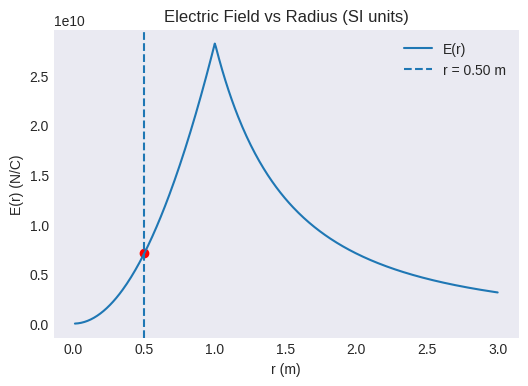

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constantes (SI)
k = 1.0  # (ajuste conforme sua modelagem)
epsilon0 = 8.85e-12  # C^2/(N·m^2)
R = 1.0  # metros

def E(r):
    if r <= R:
        return (k / (4 * epsilon0)) * r**2
    else:
        return (k * R**5) / (4 * epsilon0 * r**2)

r_values = np.linspace(0.01, 3*R, 400)
E_values = np.array([E(r) for r in r_values])

def update(r_point):
    plt.figure(figsize=(6,4))

    plt.plot(r_values, E_values, label="E(r)")
    plt.axvline(r_point, linestyle='--', label=f"r = {r_point:.2f} m")
    plt.scatter([r_point], [E(r_point)], color='red')

    plt.xlabel("r (m)")
    plt.ylabel("E(r) (N/C)")
    plt.title("Electric Field vs Radius (SI units)")

    plt.legend()
    plt.grid()

    plt.show()

slider = widgets.FloatSlider(
    value=0.5,
    min=0.01,
    max=3*R,
    step=0.01,
    description='r (m):'
)

widgets.interactive(update, r_point=slider)

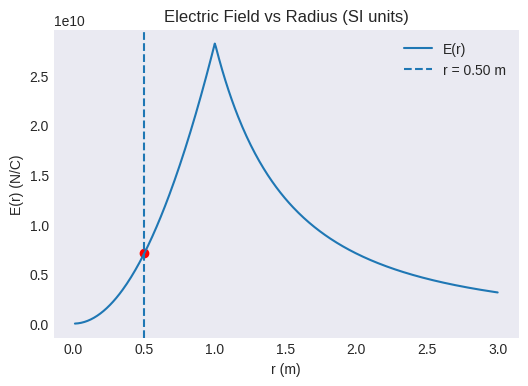

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constantes (SI)
k = 1.0  # (ajuste conforme sua modelagem)
epsilon0 = 8.85e-12  # C^2/(N·m^2)
R = 1.0  # metros

def E(r):
    if r <= R:
        return (k / (4 * epsilon0)) * r**2
    else:
        return (k * R**5) / (4 * epsilon0 * r**2)

r_values = np.linspace(0.01, 3*R, 400)
E_values = np.array([E(r) for r in r_values])

def update(r_point):
    plt.figure(figsize=(6,4))

    plt.plot(r_values, E_values, label="E(r)")
    plt.axvline(r_point, linestyle='--', label=f"r = {r_point:.2f} m")
    plt.scatter([r_point], [E(r_point)], color='red')

    plt.xlabel("r (m)")
    plt.ylabel("E(r) (N/C)")
    plt.title("Electric Field vs Radius (SI units)")

    plt.legend()
    plt.grid()

    plt.show()

slider = widgets.FloatSlider(
    value=0.5,
    min=0.01,
    max=3*R,
    step=0.01,
    description='r (m):'
)

widgets.interactive(update, r_point=slider)

Esfera com distribuição p=kr

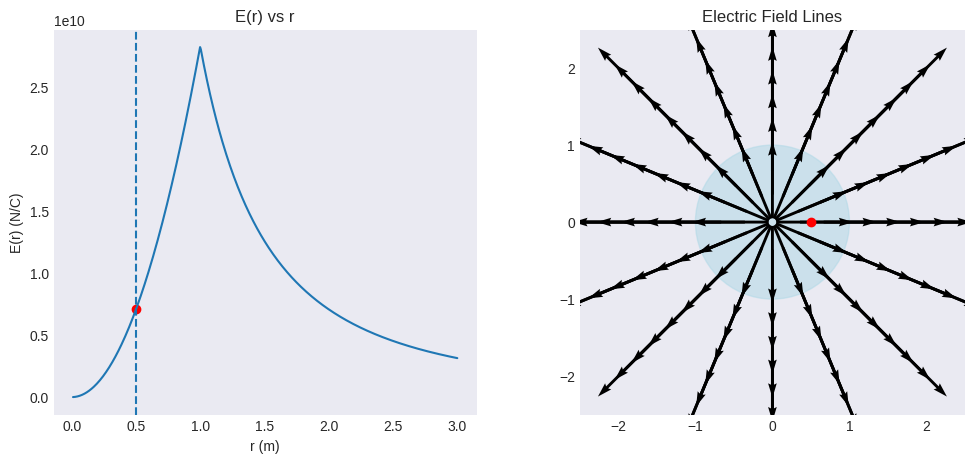

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constantes (SI)
k = 1.0
epsilon0 = 8.85e-12
R = 1.0

# Campo elétrico
def E(r):
    if r <= R:
        return (k / (4 * epsilon0)) * r**2
    else:
        return (k * R**4) / (4 * epsilon0 * r**2)

# ------------------------
# PLOT 1D + 2D
# ------------------------
def plot_all(r_point):

    fig = plt.figure(figsize=(12,5))

    # ------------------------
    # 1D: E(r)
    # ------------------------
    ax1 = fig.add_subplot(1,2,1)

    r_values = np.linspace(0.01, 3*R, 500)
    E_values = np.array([E(r) for r in r_values])

    ax1.plot(r_values, E_values)
    ax1.axvline(r_point, linestyle='--')
    ax1.scatter([r_point], [E(r_point)], color='red')

    ax1.set_xlabel("r (m)")
    ax1.set_ylabel("E(r) (N/C)")
    ax1.set_title("E(r) vs r")
    ax1.grid()

    # ------------------------
    # 2D: linhas de campo
    # ------------------------
    ax2 = fig.add_subplot(1,2,2)

    # esfera
    circle = plt.Circle((0,0), R, color='lightblue', alpha=0.5)
    ax2.add_patch(circle)

    angles = np.linspace(0, 2*np.pi, 16, endpoint=False)

    for theta in angles:
        r_vals = np.linspace(0.05, 2.5*R, 200)

        x = r_vals * np.cos(theta)
        y = r_vals * np.sin(theta)

        # setas (direção radial)
        dx = np.cos(theta)
        dy = np.sin(theta)

        ax2.quiver(
            x[::25], y[::25], dx, dy,
            angles='xy', scale_units='xy', scale=1
        )

    # ponto selecionado
    x_point = r_point * np.cos(0)
    y_point = r_point * np.sin(0)

    ax2.scatter([x_point], [y_point], color='red')

    ax2.set_xlim(-2.5*R, 2.5*R)
    ax2.set_ylim(-2.5*R, 2.5*R)
    ax2.set_aspect('equal')

    ax2.set_title("Electric Field Lines")
    ax2.grid()

    plt.show()

# Slider
slider = widgets.FloatSlider(
    value=0.5,
    min=0.01,
    max=2.5*R,
    step=0.01,
    description='r (m):'
)

widgets.interactive(plot_all, r_point=slider)

Cargas pontuais

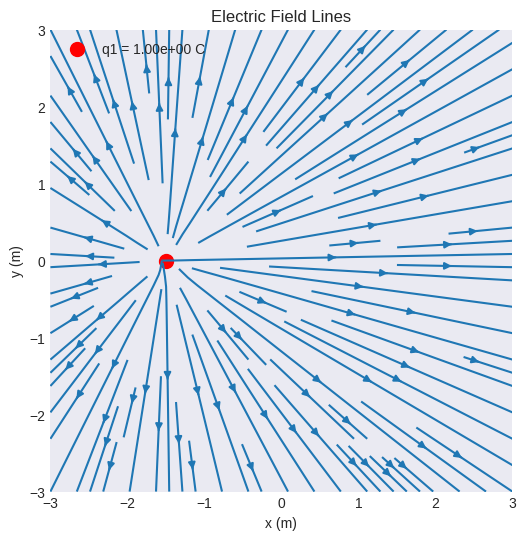

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constantes
k = 8.99e9  # 1/(4πϵ0)

# Campo de uma carga pontual
def E_point(q, rx, ry, xq, yq):
    dx = rx - xq
    dy = ry - yq

    r2 = dx**2 + dy**2
    r = np.sqrt(r2) + 1e-9  # evitar divisão por zero

    Ex = k * q * dx / (r**3)
    Ey = k * q * dy / (r**3)

    return Ex, Ey

# Campo total (1 ou 2 cargas)
def E_total(q1, x1, y1, q2=None, x2=None, y2=None):

    # grid
    x = np.linspace(-3, 3, 40)
    y = np.linspace(-3, 3, 40)
    X, Y = np.meshgrid(x, y)

    Ex, Ey = E_point(q1, X, Y, x1, y1)

    if q2 is not None:
        Ex2, Ey2 = E_point(q2, X, Y, x2, y2)
        Ex += Ex2
        Ey += Ey2

    return X, Y, Ex, Ey

# Plot
def plot_field(mode, q1, q2, sign2):

    plt.figure(figsize=(6,6))

    # Cargas (posição em metros)
    x1, y1 = -1.5, 0  # (m)

    if mode == "1 charge":
        X, Y, Ex, Ey = E_total(q1, x1, y1)

        plt.scatter(x1, y1, color='red' if q1 > 0 else 'blue', s=100,
                    label=f"q1 = {q1:.2e} C")

    else:
        x2, y2 = 1.5, 0  # (m)

        # sinal da segunda carga
        q2 = abs(q2) * sign2

        X, Y, Ex, Ey = E_total(q1, x1, y1, q2, x2, y2)

        plt.scatter(x1, y1, color='red' if q1 > 0 else 'blue', s=100,
                    label=f"q1 = {q1:.2e} C")
        plt.scatter(x2, y2, color='red' if q2 > 0 else 'blue', s=100,
                    label=f"q2 = {q2:.2e} C")

    # Linhas de campo
    plt.streamplot(X, Y, Ex, Ey, density=1.2)

    # Limites (m)
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)

    plt.gca().set_aspect('equal')

    # Rótulos com unidades SI
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title("Electric Field Lines")

    plt.legend()
    plt.grid()

    plt.show()

# Widgets
mode = widgets.Dropdown(
    options=["1 charge", "2 charges"],
    value="1 charge",
    description="Mode:"
)

q1_slider = widgets.FloatSlider(
    value=1.0,
    min=-2.0,
    max=2.0,
    step=0.1,
    description="q1 (C)"
)

q2_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=2.0,
    step=0.1,
    description="|q2| (C)"
)

sign2_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Sign q2'
)

widgets.interactive(
    plot_field,
    mode=mode,
    q1=q1_slider,
    q2=q2_slider,
    sign2=sign2_toggle
)

Esfera condutora

interactive(children=(FloatSlider(value=1.5, description='r (m):', max=2.5, min=0.01, step=0.01), ToggleButton…

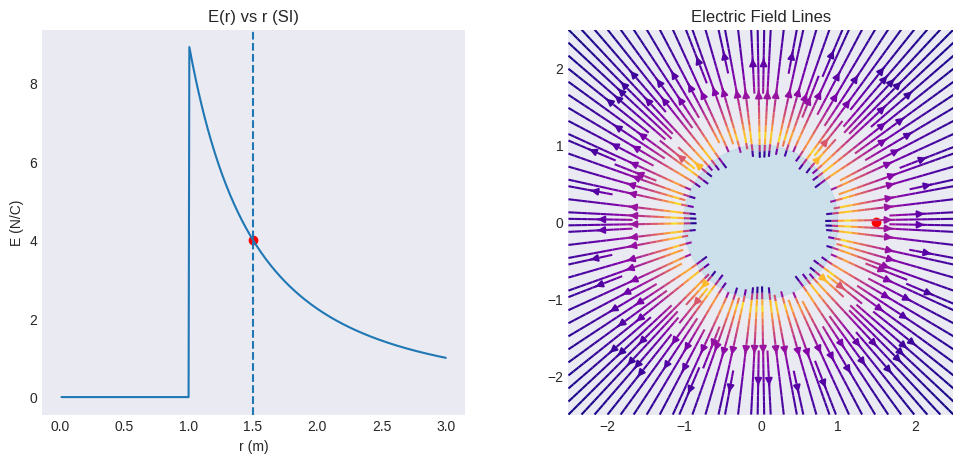

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12
k = 1 / (4 * np.pi * epsilon0)

# Raio da esfera (m)
R = 1.0

# Valor fixo da carga (magnitude)
Q0 = 1e-9  # C

# Campo elétrico
def E(r, Q):
    if r < R:
        return 0.0
    else:
        return k * Q / r**2

# Campo vetorial
def E_vector(x, y, Q):
    r = np.sqrt(x**2 + y**2) + 1e-12

    if r < R:
        return 0.0, 0.0

    Ex = k * Q * x / r**3
    Ey = k * Q * y / r**3

    return Ex, Ey

# ------------------------
# PLOT
# ------------------------
def plot_all(r_point, sign):

    Q = sign * Q0  # apenas muda o sinal

    fig = plt.figure(figsize=(12,5))

    # ========================
    # 1D
    # ========================
    ax1 = fig.add_subplot(1,2,1)

    r_values = np.linspace(0.01, 3*R, 500)
    E_values = [E(r, Q) for r in r_values]

    ax1.plot(r_values, E_values)
    ax1.axvline(r_point, linestyle='--')
    ax1.scatter([r_point], [E(r_point, Q)], color='red')

    ax1.set_xlabel("r (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("E(r) vs r (SI)")
    ax1.grid()

    # ========================
    # 2D
    # ========================
    ax2 = fig.add_subplot(1,2,2)

    x = np.linspace(-2.5*R, 2.5*R, 25)
    y = np.linspace(-2.5*R, 2.5*R, 25)
    X, Y = np.meshgrid(x, y)

    Ex = np.zeros_like(X)
    Ey = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            ex, ey = E_vector(X[i,j], Y[i,j], Q)
            Ex[i,j] = ex
            Ey[i,j] = ey

    # Esfera
    circle = plt.Circle((0,0), R, color='lightblue', alpha=0.5)
    ax2.add_patch(circle)

    # Normalização para visualização
    magnitude = np.sqrt(Ex**2 + Ey**2)
    magnitude[magnitude == 0] = 1

    Ex_dir = Ex / magnitude
    Ey_dir = Ey / magnitude

    ax2.streamplot(X, Y, Ex_dir, Ey_dir, color=magnitude, cmap='plasma', density=2)

    # ponto
    ax2.scatter([r_point], [0], color='red')

    ax2.set_xlim(-2.5*R, 2.5*R)
    ax2.set_ylim(-2.5*R, 2.5*R)
    ax2.set_aspect('equal')

    ax2.set_title("Electric Field Lines")
    ax2.grid()

    plt.show()

# ------------------------
# Widgets
# ------------------------
slider_r = widgets.FloatSlider(
    value=1.5,
    min=0.01,
    max=2.5*R,
    step=0.01,
    description='r (m):'
)

# Botões de sinal
sign_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Charge:',
)

widgets.interactive(plot_all, r_point=slider_r, sign=sign_toggle)

Esfera isolante

interactive(children=(FloatSlider(value=1.5, description='r (m):', max=2.5, min=0.01, step=0.01), ToggleButton…

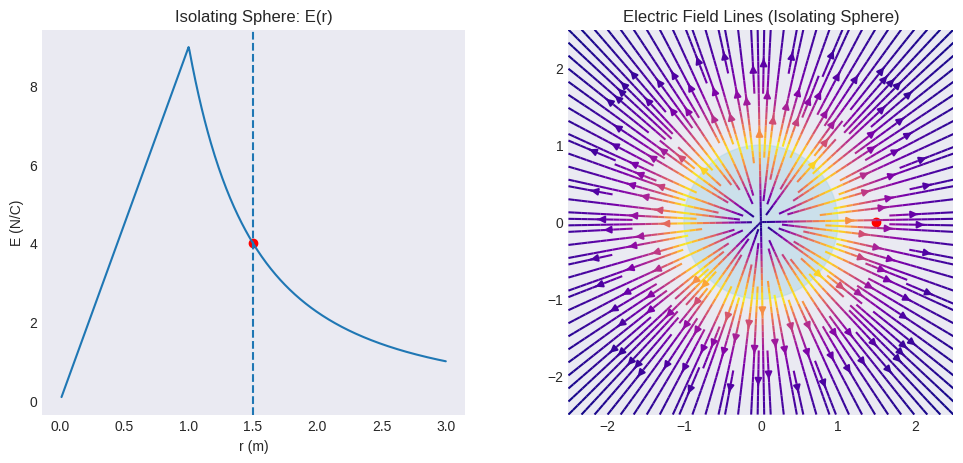

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12
k = 1 / (4 * np.pi * epsilon0)

# Raio da esfera (m)
R = 1.0

# Campo elétrico (esfera isolante)
def E(r, Q):
    if r < R:
        return k * Q * r / R**3
    else:
        return k * Q / r**2

# Campo vetorial
def E_vector(x, y, Q):
    r = np.sqrt(x**2 + y**2) + 1e-12

    if r < R:
        factor = k * Q / R**3
        return factor * x, factor * y

    factor = k * Q / r**3
    return factor * x, factor * y

# ------------------------
# PLOT
# ------------------------
def plot_all(r_point, sign):

    Q0 = 1e-9  # carga base (SI)
    Q = sign * Q0

    fig = plt.figure(figsize=(12,5))

    # ========================
    # 1D
    # ========================
    ax1 = fig.add_subplot(1,2,1)

    r_values = np.linspace(0.01, 3*R, 500)
    E_values = [E(r, Q) for r in r_values]

    ax1.plot(r_values, E_values)
    ax1.axvline(r_point, linestyle='--')
    ax1.scatter([r_point], [E(r_point, Q)], color='red')

    ax1.set_xlabel("r (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("Isolating Sphere: E(r)")
    ax1.grid()

    # ========================
    # 2D
    # ========================
    ax2 = fig.add_subplot(1,2,2)

    x = np.linspace(-2.5*R, 2.5*R, 30)
    y = np.linspace(-2.5*R, 2.5*R, 30)
    X, Y = np.meshgrid(x, y)

    Ex = np.zeros_like(X)
    Ey = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            ex, ey = E_vector(X[i,j], Y[i,j], Q)
            Ex[i,j] = ex
            Ey[i,j] = ey

    # esfera
    circle = plt.Circle((0,0), R, color='lightblue', alpha=0.5)
    ax2.add_patch(circle)

    # intensidade (cor)
    magnitude = np.sqrt(Ex**2 + Ey**2)

    ax2.streamplot(
        X, Y,
        Ex, Ey,
        color=magnitude,
        cmap='plasma',
        density=2
    )

    # ponto
    ax2.scatter([r_point], [0], color='red')

    ax2.set_xlim(-2.5*R, 2.5*R)
    ax2.set_ylim(-2.5*R, 2.5*R)
    ax2.set_aspect('equal')

    ax2.set_title("Electric Field Lines (Isolating Sphere)")
    ax2.grid()

    plt.show()

# ------------------------
# Widgets
# ------------------------
slider_r = widgets.FloatSlider(
    value=1.5,
    min=0.01,
    max=2.5*R,
    step=0.01,
    description='r (m):'
)

sign_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Charge:'
)

widgets.interactive(plot_all, r_point=slider_r, sign=sign_toggle)

Fio elétrico carregado

interactive(children=(FloatSlider(value=1.5, description='r (m):', max=3.0, min=0.1, step=0.01), ToggleButtons…

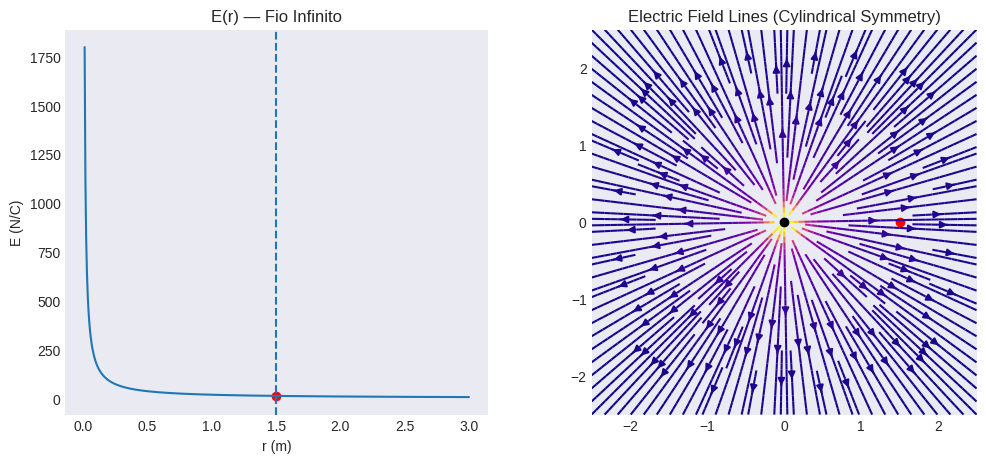

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12

# Densidade linear (C/m)
lambda0 = 1e-9  # valor base

# Campo elétrico (fio infinito)
def E(r, lam):
    return lam / (2 * np.pi * epsilon0 * r)

# Campo vetorial
def E_vector(x, y, lam):
    r = np.sqrt(x**2 + y**2) + 1e-12

    Ex = lam / (2 * np.pi * epsilon0) * x / r**2
    Ey = lam / (2 * np.pi * epsilon0) * y / r**2

    return Ex, Ey

# ------------------------
# PLOT
# ------------------------
def plot_all(r_point, sign):

    lam = sign * lambda0

    fig = plt.figure(figsize=(12,5))

    # ========================
    # 1D: E(r)
    # ========================
    ax1 = fig.add_subplot(1,2,1)

    r_values = np.linspace(0.01, 3, 500)
    E_values = E(r_values, lam)

    ax1.plot(r_values, E_values)
    ax1.axvline(r_point, linestyle='--')
    ax1.scatter([r_point], [E(r_point, lam)], color='red')

    ax1.set_xlabel("r (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("E(r) — Fio Infinito")
    ax1.grid()

    # ========================
    # 2D: linhas de campo
    # ========================
    ax2 = fig.add_subplot(1,2,2)

    x = np.linspace(-2.5, 2.5, 30)
    y = np.linspace(-2.5, 2.5, 30)
    X, Y = np.meshgrid(x, y)

    Ex = np.zeros_like(X)
    Ey = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            ex, ey = E_vector(X[i,j], Y[i,j], lam)
            Ex[i,j] = ex
            Ey[i,j] = ey

    # normalização (direção)
    magnitude = np.sqrt(Ex**2 + Ey**2)
    magnitude[magnitude == 0] = 1

    Ex_dir = Ex / magnitude
    Ey_dir = Ey / magnitude

    # linhas de campo
    ax2.streamplot(X, Y, Ex_dir, Ey_dir, color=magnitude, cmap='plasma', density=2)

    # fio (centro)
    ax2.plot(0, 0, 'ko', markersize=6)

    # ponto
    ax2.scatter([r_point], [0], color='red')

    ax2.set_xlim(-2.5, 2.5)
    ax2.set_ylim(-2.5, 2.5)
    ax2.set_aspect('equal')

    ax2.set_title("Electric Field Lines (Cylindrical Symmetry)")
    ax2.grid()

    plt.show()

# ------------------------
# Widgets
# ------------------------
slider_r = widgets.FloatSlider(
    value=1.5,
    min=0.1,
    max=3,
    step=0.01,
    description='r (m):'
)

sign_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Charge:'
)

widgets.interactive(plot_all, r_point=slider_r, sign=sign_toggle)

Cilindro isolante

interactive(children=(FloatSlider(value=1.5, description='r (m):', max=2.5, min=0.01, step=0.01), ToggleButton…

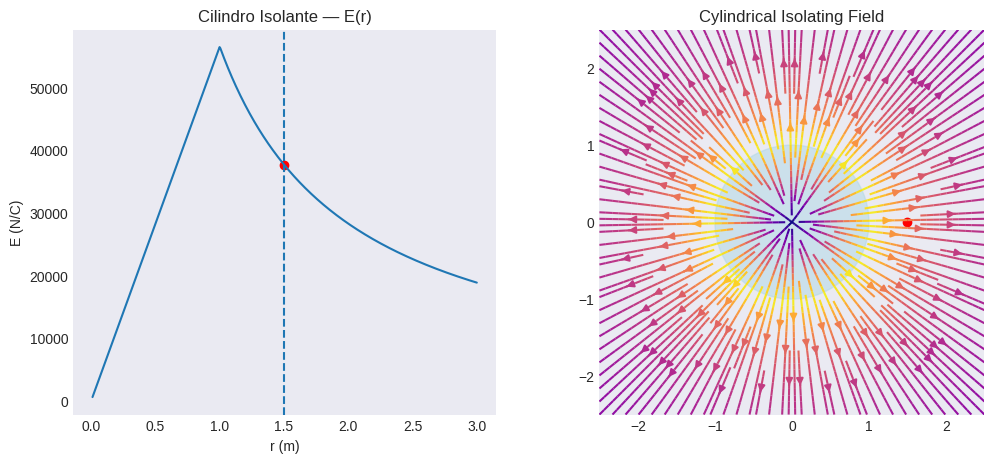

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12

# Raio do cilindro (m)
R = 1.0

# Densidade volumétrica (C/m^3)
rho0 = 1e-6

# Campo elétrico (escala radial)
def E_scalar(rho, r):
    if r < R:
        return rho * r / (2 * epsilon0)
    else:
        return rho * R**2 / (2 * epsilon0 * r)

# Campo vetorial
def E_vector(x, y, rho):
    r = np.sqrt(x**2 + y**2) + 1e-12

    if r < R:
        factor = rho / (2 * epsilon0)
        return factor * x, factor * y

    factor = rho * R**2 / (2 * epsilon0 * r**2)
    return factor * x, factor * y

# ------------------------
# PLOT
# ------------------------
def plot_all(r_point, sign):

    rho = sign * rho0

    fig = plt.figure(figsize=(12,5))

    # ========================
    # 1D: E(r)
    # ========================
    ax1 = fig.add_subplot(1,2,1)

    r_values = np.linspace(0.01, 3*R, 500)
    E_values = [E_scalar(rho, r) for r in r_values]

    ax1.plot(r_values, E_values)
    ax1.axvline(r_point, linestyle='--')
    ax1.scatter([r_point], [E_scalar(rho, r_point)], color='red')

    ax1.set_xlabel("r (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("Cilindro Isolante — E(r)")
    ax1.grid()

    # ========================
    # 2D: linhas de campo
    # ========================
    ax2 = fig.add_subplot(1,2,2)

    x = np.linspace(-2.5*R, 2.5*R, 35)
    y = np.linspace(-2.5*R, 2.5*R, 35)
    X, Y = np.meshgrid(x, y)

    Ex = np.zeros_like(X)
    Ey = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            ex, ey = E_vector(X[i,j], Y[i,j], rho)
            Ex[i,j] = ex
            Ey[i,j] = ey

    # cilindro (representado como círculo)
    circle = plt.Circle((0,0), R, color='lightblue', alpha=0.5)
    ax2.add_patch(circle)

    # magnitude
    magnitude = np.sqrt(Ex**2 + Ey**2)

    # normalização
    magnitude[magnitude == 0] = 1
    Ex_dir = Ex / magnitude
    Ey_dir = Ey / magnitude

    ax2.streamplot(
        X, Y,
        Ex_dir, Ey_dir,
        color=magnitude,
        cmap='plasma',
        density=2
    )

    # ponto
    ax2.scatter([r_point], [0], color='red')

    ax2.set_xlim(-2.5*R, 2.5*R)
    ax2.set_ylim(-2.5*R, 2.5*R)
    ax2.set_aspect('equal')

    ax2.set_title("Cylindrical Isolating Field")
    ax2.grid()

    plt.show()

# ------------------------
# Widgets
# ------------------------
slider_r = widgets.FloatSlider(
    value=1.5,
    min=0.01,
    max=2.5*R,
    step=0.01,
    description='r (m):'
)

sign_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Charge:'
)

widgets.interactive(plot_all, r_point=slider_r, sign=sign_toggle)

Cilindro condutor

interactive(children=(FloatSlider(value=1.5, description='r (m):', max=2.5, min=0.01, step=0.01), ToggleButton…

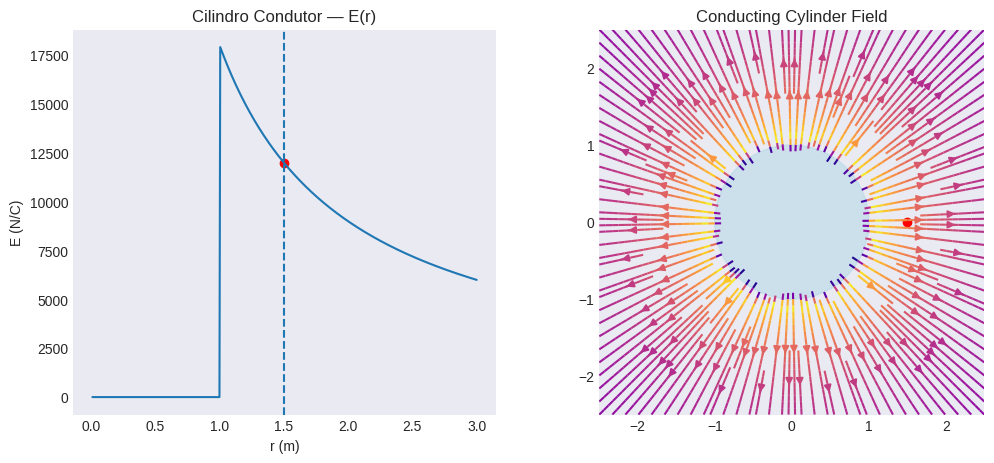

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12

R = 1.0

# densidade linear (C/m)
lambda0 = 1e-6

# campo escalar
def E_scalar(rho_sign, r):

    lam = rho_sign * lambda0

    if r < R:
        return 0.0
    else:
        return lam / (2 * np.pi * epsilon0 * r)

# campo vetorial
def E_vector(x, y, sign):

    r = np.sqrt(x**2 + y**2) + 1e-12

    lam = sign * lambda0

    if r < R:
        return 0.0, 0.0

    factor = lam / (2 * np.pi * epsilon0 * r**2)

    return factor * x, factor * y

# ------------------------
# PLOT
# ------------------------
def plot_condutor(r_point, sign):

    fig = plt.figure(figsize=(12,5))

    # ========================
    # 1D
    # ========================
    ax1 = fig.add_subplot(1,2,1)

    r_values = np.linspace(0.01, 3*R, 500)
    E_values = [E_scalar(sign, r) for r in r_values]

    ax1.plot(r_values, E_values)
    ax1.axvline(r_point, linestyle='--')
    ax1.scatter([r_point], [E_scalar(sign, r_point)], color='red')

    ax1.set_xlabel("r (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("Cilindro Condutor — E(r)")
    ax1.grid()

    # ========================
    # 2D
    # ========================
    ax2 = fig.add_subplot(1,2,2)

    x = np.linspace(-2.5*R, 2.5*R, 35)
    y = np.linspace(-2.5*R, 2.5*R, 35)
    X, Y = np.meshgrid(x, y)

    Ex = np.zeros_like(X)
    Ey = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            ex, ey = E_vector(X[i,j], Y[i,j], sign)
            Ex[i,j] = ex
            Ey[i,j] = ey

    # cilindro
    circle = plt.Circle((0,0), R, color='lightblue', alpha=0.5)
    ax2.add_patch(circle)

    # normalização
    mag = np.sqrt(Ex**2 + Ey**2)
    mag[mag == 0] = 1

    ax2.streamplot(
        X, Y,
        Ex/mag, Ey/mag,
        color=mag,
        cmap='plasma',
        density=2
    )

    ax2.scatter([r_point], [0], color='red')

    ax2.set_xlim(-2.5*R, 2.5*R)
    ax2.set_ylim(-2.5*R, 2.5*R)
    ax2.set_aspect('equal')

    ax2.set_title("Conducting Cylinder Field")
    ax2.grid()

    plt.show()

# ------------------------
# Widgets
# ------------------------
slider_r = widgets.FloatSlider(
    value=1.5,
    min=0.01,
    max=2.5*R,
    step=0.01,
    description='r (m):'
)

sign_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Charge:'
)

widgets.interactive(plot_condutor, r_point=slider_r, sign=sign_toggle)

Casca cilíndrica

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12

R = 1.0

# densidade linear (C/m)
lambda0 = 1e-6

# campo escalar
def E_scalar(sign, r):

    lam = sign * lambda0

    if r < R:
        return 0.0
    else:
        return lam / (2 * np.pi * epsilon0 * r)

# campo vetorial
def E_vector(x, y, sign):

    r = np.sqrt(x**2 + y**2) + 1e-12

    lam = sign * lambda0

    if r < R:
        return 0.0, 0.0

    factor = lam / (2 * np.pi * epsilon0 * r**2)

    return factor * x, factor * y

# ------------------------
# PLOT
# ------------------------
def plot_shell(r_point, sign):

    fig = plt.figure(figsize=(12,5))

    # ========================
    # 1D
    # ========================
    ax1 = fig.add_subplot(1,2,1)

    r_values = np.linspace(0.01, 3*R, 500)
    E_values = [E_scalar(sign, r) for r in r_values]

    ax1.plot(r_values, E_values)
    ax1.axvline(r_point, linestyle='--')
    ax1.scatter([r_point], [E_scalar(sign, r_point)], color='red')

    ax1.set_xlabel("r (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("Cylindrical Shell — E(r)")
    ax1.grid()

    # ========================
    # 2D
    # ========================
    ax2 = fig.add_subplot(1,2,2)

    x = np.linspace(-2.5*R, 2.5*R, 35)
    y = np.linspace(-2.5*R, 2.5*R, 35)
    X, Y = np.meshgrid(x, y)

    Ex = np.zeros_like(X)
    Ey = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            ex, ey = E_vector(X[i,j], Y[i,j], sign)
            Ex[i,j] = ex
            Ey[i,j] = ey

    # casca (círculo)
    circle = plt.Circle((0,0), R, color='lightblue', fill=False, linewidth=2)
    ax2.add_patch(circle)

    # normalização
    mag = np.sqrt(Ex**2 + Ey**2)
    mag[mag == 0] = 1

    ax2.streamplot(
        X, Y,
        Ex/mag, Ey/mag,
        color=mag,
        cmap='plasma',
        density=2
    )

    ax2.scatter([r_point], [0], color='red')

    ax2.set_xlim(-2.5*R, 2.5*R)
    ax2.set_ylim(-2.5*R, 2.5*R)
    ax2.set_aspect('equal')

    ax2.set_title("Cylindrical Shell Field")
    ax2.grid()

    plt.show()

# ------------------------
# Widgets
# ------------------------
slider_r = widgets.FloatSlider(
    value=1.5,
    min=0.01,
    max=2.5*R,
    step=0.01,
    description='r (m):'
)

sign_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Charge:'
)

widgets.interactive(plot_shell, r_point=slider_r, sign=sign_toggle)

Plano infinito

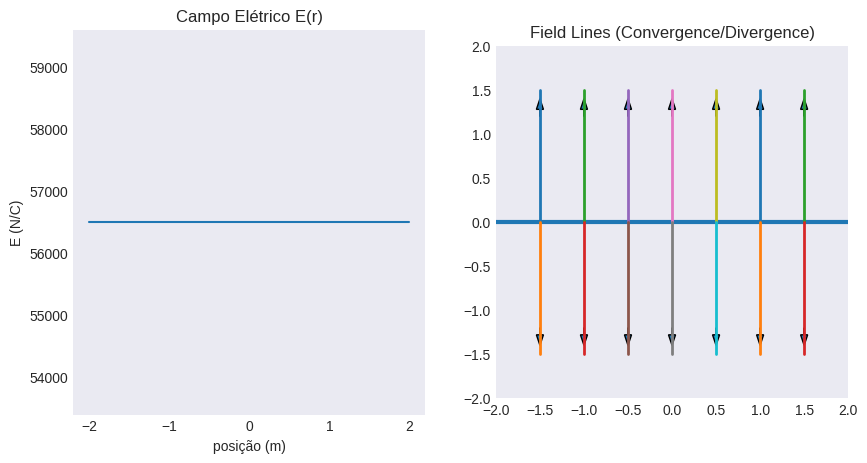

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12

sigma0 = 1e-6  # C/m²

def plot_field(sign):

    sigma = sign * sigma0
    E = sigma / (2 * epsilon0)  # N/C

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

    # ========================
    # 1D: campo constante
    # ========================
    y = np.linspace(-2, 2, 200)
    E_values = np.ones_like(y) * E

    ax1.plot(y, E_values)
    ax1.set_xlabel("posição (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("Campo Elétrico E(r)")
    ax1.grid()

    # ========================
    # 2D: linhas de campo
    # ========================
    ax2.set_xlim(-2, 2)
    ax2.set_ylim(-2, 2)
    ax2.set_aspect('equal')

    # placa no centro
    ax2.axhline(0, linewidth=3)

    # posições laterais das linhas
    x_positions = np.linspace(-1.5, 1.5, 7)

    for x in x_positions:
        if sigma > 0:
            # SAINDO (divergente)

            # acima
            ax2.plot([x, x], [0, 1.5], linewidth=2)
            ax2.arrow(x, 1.2, 0, 0.2, head_width=0.08, length_includes_head=True)

            # abaixo
            ax2.plot([x, x], [0, -1.5], linewidth=2)
            ax2.arrow(x, -1.2, 0, -0.2, head_width=0.08, length_includes_head=True)

        else:
            # ENTRANDO (convergente)

            # acima
            ax2.plot([x, x], [1.5, 0], linewidth=2)
            ax2.arrow(x, 1.2, 0, -0.2, head_width=0.08, length_includes_head=True)

            # abaixo
            ax2.plot([x, x], [-1.5, 0], linewidth=2)
            ax2.arrow(x, -1.2, 0, 0.2, head_width=0.08, length_includes_head=True)

    ax2.set_title("Field Lines (Convergence/Divergence)")
    ax2.grid()

    plt.show()


# Widget
sign_toggle = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Placa:'
)

widgets.interactive(plot_field, sign=sign_toggle)

Capacitor de placas paralelas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Constante SI
epsilon0 = 8.85e-12

sigma0 = 1e-6  # C/m²

def plot_capacitor(sign1, sign2):

    sigma1 = sign1 * sigma0
    sigma2 = sign2 * sigma0

    # campos individuais
    E1 = sigma1 / (2 * epsilon0)
    E2 = sigma2 / (2 * epsilon0)

    # região entre placas (campo uniforme resultante)
    E_between = E1 - E2

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    # ========================
    # 1D: campo ao longo do eixo
    # ========================
    y = np.linspace(-3, 3, 300)
    E_values = np.zeros_like(y)

    for i, yi in enumerate(y):
        if -1 < yi < 1:
            E_values[i] = E_between
        else:
            # fora: cancelamento aproximado
            E_values[i] = 0

    ax1.plot(y, E_values)

    ax1.axvline(-1, linestyle='--')
    ax1.axvline(1, linestyle='--')

    ax1.set_xlabel("posição (m)")
    ax1.set_ylabel("E (N/C)")
    ax1.set_title("Campo Resultante (Capacitor)")
    ax1.grid()

    # ========================
    # 2D: linhas de campo
    # ========================
    ax2.set_xlim(-2, 2)
    ax2.set_ylim(-2, 2)
    ax2.set_aspect('equal')

    # placas
    ax2.axhline(1, linewidth=3)
    ax2.axhline(-1, linewidth=3)

    x_positions = np.linspace(-1.5, 1.5, 7)

    for x in x_positions:

        if abs(E_between) > 0:

            # entre as placas
            ax2.plot([x, x], [-1, 1], linewidth=2)

            if E_between > 0:
                ax2.arrow(x, 0.8, 0, 0.2, head_width=0.08)
                ax2.arrow(x, -0.8, 0, -0.2, head_width=0.08)
            else:
                ax2.arrow(x, 0.8, 0, -0.2, head_width=0.08)
                ax2.arrow(x, -0.8, 0, 0.2, head_width=0.08)

    ax2.set_title("Field Lines (Superposition)")
    ax2.grid()

    plt.show()


# ========================
# Widgets
# ========================
sign1 = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Placa 1:'
)

sign2 = widgets.ToggleButtons(
    options=[('+', 1), ('-', -1)],
    description='Placa 2:'
)

widgets.interactive(plot_capacitor, sign1=sign1, sign2=sign2)

Resfriamento de Newton

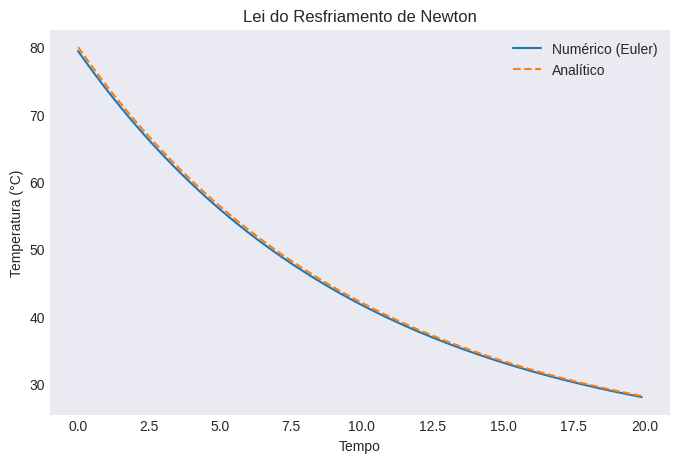

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ---------------------------
# SIMULAÇÃO NUMÉRICA
# ---------------------------
def resfriamento(T0, Tamb, k, t_max=20, dt=0.1):

    t_vals = []
    T_vals = []

    T = T0

    for t in np.arange(0, t_max, dt):

        dTdt = -k * (T - Tamb)

        T += dTdt * dt

        t_vals.append(t)
        T_vals.append(T)

    return np.array(t_vals), np.array(T_vals)


# ---------------------------
# SOLUÇÃO ANALÍTICA
# ---------------------------
def solucao_analitica(T0, Tamb, k, t):
    return Tamb + (T0 - Tamb) * np.exp(-k * t)


# ---------------------------
# PLOT
# ---------------------------
def plotar(T0, Tamb, k):

    t, T_num = resfriamento(T0, Tamb, k)

    T_analitico = solucao_analitica(T0, Tamb, k, t)

    plt.figure(figsize=(8,5))

    plt.plot(t, T_num, label="Numérico (Euler)")
    plt.plot(t, T_analitico, '--', label="Analítico")

    plt.xlabel("Tempo")
    plt.ylabel("Temperatura (°C)")
    plt.title("Lei do Resfriamento de Newton")

    plt.legend()
    plt.grid()

    plt.show()


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    plotar,
    T0=widgets.FloatSlider(min=10, max=100, step=1, value=80, description="T inicial"),
    Tamb=widgets.FloatSlider(min=0, max=30, step=1, value=20, description="T ambiente"),
    k=widgets.FloatSlider(min=0.01, max=1, step=0.01, value=0.1, description="k")
);

Pistão ante gás ideal

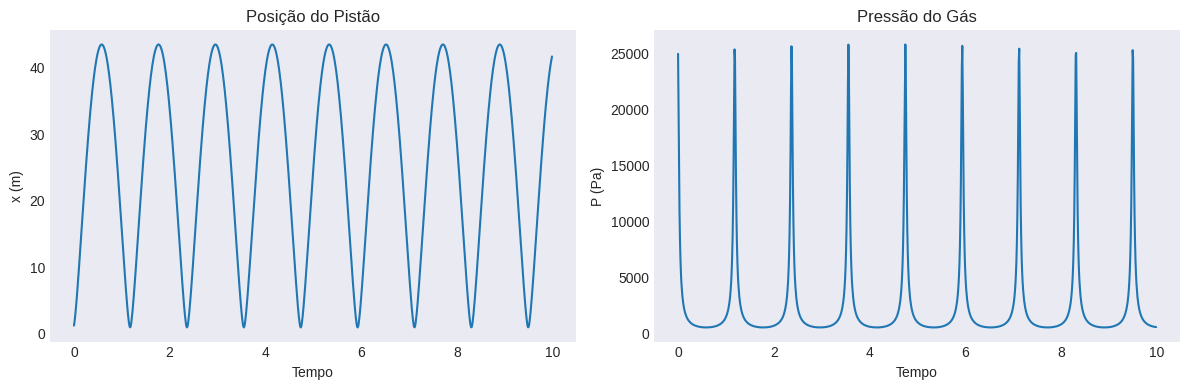

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

R = 8.314  # constante dos gases

# ---------------------------
# SIMULAÇÃO
# ---------------------------
def simular_gas(n, T, A, m, k, x0, v0, t_max=10, dt=0.01):

    x = x0  # posição do pistão
    v = v0  # velocidade

    t_vals = []
    x_vals = []
    v_vals = []
    P_vals = []

    for t in np.arange(0, t_max, dt):

        V = A * x

        # pressão interna (gás ideal)
        P = (n * R * T) / V

        # força do gás
        F = P * A

        # força externa (tipo mola)
        F_ext = -k * x

        # segunda lei de Newton
        a = (F + F_ext) / m

        v += a * dt
        x += v * dt

        t_vals.append(t)
        x_vals.append(x)
        v_vals.append(v)
        P_vals.append(P)

    return np.array(t_vals), np.array(x_vals), np.array(P_vals)


# ---------------------------
# PLOT
# ---------------------------
def plotar(n, T, A, m, k, x0):

    t, x, P = simular_gas(n, T, A, m, k, x0, 0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    ax1.plot(t, x)
    ax1.set_title("Posição do Pistão")
    ax1.set_xlabel("Tempo")
    ax1.set_ylabel("x (m)")
    ax1.grid()

    ax2.plot(t, P)
    ax2.set_title("Pressão do Gás")
    ax2.set_xlabel("Tempo")
    ax2.set_ylabel("P (Pa)")
    ax2.grid()

    plt.tight_layout()
    plt.show()


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    plotar,
    n=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="n (mol)"),
    T=widgets.FloatSlider(min=200, max=500, step=10, value=300, description="T (K)"),
    A=widgets.FloatSlider(min=0.01, max=1, step=0.01, value=0.1, description="Área (m²)"),
    m=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description="massa"),
    k=widgets.FloatSlider(min=0, max=100, step=1, value=10, description="k"),
    x0=widgets.FloatSlider(min=0.1, max=2, step=0.1, value=1, description="x₀")
);

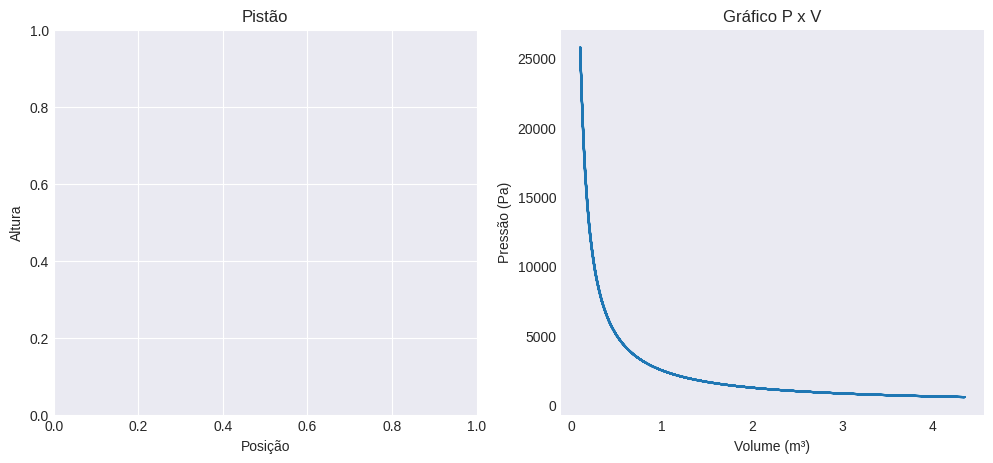

<function __main__.plotar(n, T, A, m, k, x0)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

R = 8.314

# =========================
# SIMULAÇÃO
# =========================
def simular(n, T, A, m, k, x0, v0, t_max=5, dt=0.01):

    x = x0
    v = v0

    t_vals, x_vals, P_vals, V_vals = [], [], [], []

    for t in np.arange(0, t_max, dt):

        V = A * x

        # pressão do gás
        P = (n * R * T) / V

        # forças
        F_gas = P * A
        F_ext = -k * x

        # dinâmica
        a = (F_gas + F_ext) / m

        v += a * dt
        x += v * dt

        t_vals.append(t)
        x_vals.append(x)
        P_vals.append(P)
        V_vals.append(V)

    return np.array(t_vals), np.array(x_vals), np.array(P_vals), np.array(V_vals)


# =========================
# ANIMAÇÃO + GRÁFICO
# =========================
def plotar(n, T, A, m, k, x0):

    t, x, P, V = simular(n, T, A, m, k, x0, 0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    # =====================
    # ANIMAÇÃO DO PISTÃO
    # =====================
    ax1.set_title("Pistão")
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("Posição")
    ax1.set_ylabel("Altura")

    # desenha pistão como linha
    piston_line, = ax1.plot([0.3, 0.7], [x[0], x[0]], lw=4)

    # =====================
    # GRÁFICO P x V
    # =====================
    ax2.set_title("Gráfico P x V")
    ax2.set_xlabel("Volume (m³)")
    ax2.set_ylabel("Pressão (Pa)")
    ax2.grid()

    curve, = ax2.plot([], [])

    # =====================
    # ANIMAÇÃO
    # =====================
    for i in range(len(t)):

        # atualiza pistão
        piston_line.set_ydata([x[i], x[i]])

        # atualiza curva PV
        curve.set_data(V[:i], P[:i])

        ax2.relim()
        ax2.autoscale_view()

        clear_output(wait=True)
        display(fig)
        plt.pause(0.01)

    plt.show()


# =========================
# INTERFACE
# =========================
widgets.interact(
    plotar,
    n=widgets.FloatSlider(min=0.1, max=5, step=0.1, value=1, description="n"),
    T=widgets.FloatSlider(min=200, max=500, step=10, value=300, description="T"),
    A=widgets.FloatSlider(min=0.01, max=1, step=0.01, value=0.1, description="Área"),
    m=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description="massa"),
    k=widgets.FloatSlider(min=0, max=100, step=1, value=10, description="k"),
    x0=widgets.FloatSlider(min=0.1, max=2, step=0.1, value=1, description="x₀")
)

P x V

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

R = 8.314

def Cv_gas(tipo):
    if tipo == "monoatomico":
        return 1.5 * R
    elif tipo == "diatomico":
        return 2.5 * R
    else:
        return 3.0 * R


def simular(tipo, processo, Q_rate):

    Cv = Cv_gas(tipo)

    n = 1
    A = 0.1

    x = 1.0
    v = 0.0
    T = 300

    V_list = []
    P_list = []

    dt = 0.01

    for _ in range(500):

        V = A * x
        P = (n * R * T) / V

        # calor
        dQ = Q_rate * dt

        # trabalho
        dV = A * v * dt
        dW = P * dV

        # -----------------------
        # PROCESSOS
        # -----------------------

        if processo == "isotermico":
            # ΔU = 0 → T constante
            dT = 0
            dQ = dW  # energia entra igual ao trabalho

        elif processo == "isobarico":
            # manter pressão constante
            # ajuste de T para manter P ~ constante
            dT = (dQ - dW) / (n * Cv)

        elif processo == "isocorico":
            # V constante
            x = x
            v = 0
            dW = 0
            dT = dQ / (n * Cv)

        elif processo == "adiabatico":
            # Q = 0
            dQ = 0
            dT = -dW / (n * Cv)

        else:
            # caso livre
            dT = (dQ - dW) / (n * Cv)

        # atualiza temperatura
        T += dT

        # dinâmica do pistão (simples)
        F = P * A
        a = F / 1.0

        v += a * dt
        x += v * dt

        V_list.append(V)
        P_list.append(P)

    return V_list, P_list


def plotar(tipo, processo, Q_rate):

    V, P = simular(tipo, processo, Q_rate)

    clear_output(wait=True)

    plt.figure(figsize=(6,5))
    plt.plot(V, P)
    plt.xlabel("Volume (m³)")
    plt.ylabel("Pressão (Pa)")
    plt.title(f"{tipo} - {processo}")
    plt.grid()
    plt.show()


widgets.interact(
    plotar,
    tipo=widgets.Dropdown(
        options=["monoatomico", "diatomico", "poliatomico"],
        value="monoatomico",
        description="Gás"
    ),
    processo=widgets.Dropdown(
        options=["isotermico", "isobarico", "isocorico", "adiabatico"],
        value="isotermico",
        description="Processo"
    ),
    Q_rate=widgets.FloatSlider(
        min=-500,
        max=500,
        step=10,
        value=50,
        description="Calor"
    )
)

P x V (de forma teórica)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

R = 8.314

# ---------------------------
# Cv
# ---------------------------
def Cv(tipo):
    if tipo == "monoatomico":
        return 1.5 * R
    elif tipo == "diatomico":
        return 2.5 * R
    else:
        return 3.0 * R


# ---------------------------
# SIMULAÇÃO
# ---------------------------
def simular(tipo, processo, n_mols, N=200):

    Cv_val = Cv(tipo)

    V = np.linspace(0.1, 2, N)
    P = np.zeros(N)

    T0 = 300

    if processo == "isotermico":

        for i in range(N):
            P[i] = (n_mols * R * T0) / V[i]

    elif processo == "isobarico":

        P_const = 1e5
        for i in range(N):
            P[i] = P_const

    elif processo == "isocorico":

        V_const = 1.0
        for i in range(N):
            P[i] = (n_mols * R * T0) / V_const

    elif processo == "adiabatico":

        gamma = Cv_val / (Cv_val - R)
        K = n_mols * R * T0 * (V[0] ** (gamma - 1))

        for i in range(N):
            P[i] = K / (V[i] ** gamma)

    return V, P


# ---------------------------
# TRABALHO (área sob a curva)
# ---------------------------
def calcular_trabalho(V, P):

    W = np.trapz(P, V)
    return W


# ---------------------------
# PLOT
# ---------------------------
def plotar(tipo, processo, n_mols):

    V, P = simular(tipo, processo, n_mols)

    W = calcular_trabalho(V, P)

    plt.figure(figsize=(6,5))

    plt.plot(V, P, label="Processo")

    # Sombrear área
    plt.fill_between(V, P, alpha=0.3)

    plt.xlabel("Volume (m³)")
    plt.ylabel("Pressão (Pa)")
    plt.title(f"{tipo} - {processo}")

    plt.text(
        0.5, max(P)*0.8,
        f"Trabalho ≈ {W:.2f} J",
        fontsize=10
    )

    plt.grid()
    plt.legend()
    plt.show()


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    plotar,
    tipo=widgets.Dropdown(
        options=["monoatomico", "diatomico", "poliatomico"],
        value="monoatomico",
        description="Gás"
    ),
    processo=widgets.Dropdown(
        options=["isotermico", "isobarico", "isocorico", "adiabatico"],
        value="isotermico",
        description="Processo"
    ),
    n_mols=widgets.FloatSlider(
        value=1.0,
        min=0.1,
        max=5.0,
        step=0.1,
        description="n (mol)"
    )
)

Primeira Lei da Termodinâmica

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

R = 8.314

# ---------------------------
# PROPRIEDADES
# ---------------------------
def Cv(tipo):
    if tipo == "monoatomico":
        return 1.5 * R
    elif tipo == "diatomico":
        return 2.5 * R
    else:
        return 3.0 * R


def gamma(tipo):
    return (Cv(tipo) + R) / Cv(tipo)


# ---------------------------
# CLASSIFICAÇÃO FÍSICA
# ---------------------------
def classificar(tipo, n, V_i, V_f, T_i, T_f, tol=1e-2):

    P_i = (n * R * T_i) / V_i
    P_f = (n * R * T_f) / V_f

    g = gamma(tipo)

    # ---------------------------
    # ISOCÓRICO (Gay-Lussac)
    # ---------------------------
    if abs(V_i - V_f) / V_i < tol:
        if abs(P_i - P_f) / P_i < tol:
            return "Isocórico (Gay-Lussac)"

    # ---------------------------
    # ISOBÁRICO (Charles)
    # ---------------------------
    if abs(P_i - P_f) / P_i < tol:
        if abs(V_i / T_i - V_f / T_f) < tol:
            return "Isobárico (Charles)"

    # ---------------------------
    # ISOTÉRMICO (Boyle)
    # ---------------------------
    if abs(T_i - T_f) / T_i < tol:
        if abs(P_i * V_i - P_f * V_f) / (P_i * V_i) < tol:
            return "Isotérmico (Boyle)"

    # ---------------------------
    # ADIABÁTICO
    # ---------------------------
    K_i = P_i * (V_i ** g)
    K_f = P_f * (V_f ** g)

    if abs(K_i - K_f) / K_i < tol:
        return "Adiabático"

    return "Processo geral"


# ---------------------------
# SIMULAÇÃO
# ---------------------------
def simular(n, V_i, V_f, T_i, T_f, N=200):

    V = np.linspace(V_i, V_f, N)
    T = np.linspace(T_i, T_f, N)
    P = (n * R * T) / V

    return V, P, T


# ---------------------------
# TRABALHO
# ---------------------------
def trabalho(V, P):
    return np.trapz(P, V)


# ---------------------------
# ΔU
# ---------------------------
def delta_U(n, Cv_val, T_i, T_f):
    return n * Cv_val * (T_f - T_i)


# ---------------------------
# PLOT
# ---------------------------
def plotar(tipo, n, V_i, V_f, T_i, T_f):

    V, P, T = simular(n, V_i, V_f, T_i, T_f)

    Cv_val = Cv(tipo)

    W = trabalho(V, P)
    dU = delta_U(n, Cv_val, T_i, T_f)
    Q = dU + W

    processo = classificar(tipo, n, V_i, V_f, T_i, T_f)

    plt.figure(figsize=(6,5))

    plt.plot(V, P, label="Processo")
    plt.fill_between(V, P, alpha=0.3)

    plt.scatter([V_i, V_f], [P[0], P[-1]])

    plt.xlabel("Volume (m³)")
    plt.ylabel("Pressão (Pa)")
    plt.title(processo)

    plt.grid()
    plt.legend()

    plt.text(
        0.05, 0.95,
        f"W = {W:.2f} J\nΔU = {dU:.2f} J\nQ = {Q:.2f} J",
        transform=plt.gca().transAxes,
        verticalalignment='top'
    )

    plt.show()


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    plotar,
    tipo=widgets.Dropdown(
        options=["monoatomico", "diatomico", "poliatomico"],
        value="monoatomico",
        description="Gás"
    ),
    n=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description="n"),
    V_i=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description="V_i"),
    V_f=widgets.FloatSlider(value=2, min=0.1, max=5, step=0.1, description="V_f"),
    T_i=widgets.FloatSlider(value=300, min=100, max=1000, step=10, description="T_i"),
    T_f=widgets.FloatSlider(value=400, min=100, max=1000, step=10, description="T_f")
)

Primeira Lei da Termodinâmica (pistão)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets

R = 8.314

# ---------------------------
# PROPRIEDADES
# ---------------------------
def gamma(tipo):
    if tipo == "monoatomico":
        return 5/3
    elif tipo == "diatomico":
        return 7/5
    else:
        return 4/3


# ---------------------------
# SIMULAÇÃO DO PROCESSO
# ---------------------------
def gerar_dados(processo, n, V_i, V_f, T_i, T_f, N=200):

    V = np.linspace(V_i, V_f, N)
    P = np.zeros(N)
    T = np.zeros(N)

    if processo == "isotermico":
        T[:] = T_i
        P = (n * R * T_i) / V

    elif processo == "isobarico":
        P[:] = (n * R * T_i) / V_i
        T = (P * V) / (n * R)

    elif processo == "isocorico":
        V[:] = V_i
        T = np.linspace(T_i, T_f, N)
        P = (n * R * T) / V_i

    elif processo == "adiabatico":
        g = gamma("monoatomico")

        K = (n * R * T_i) * (V_i ** (g - 1))

        for i in range(N):
            T[i] = T_i * (V_i / V[i]) ** (g - 1)
            P[i] = K / (V[i] ** g)

    return V, P, T


# ---------------------------
# ANIMAÇÃO
# ---------------------------
def animar(processo, n, V_i, V_f, T_i, T_f):

    V, P, T = gerar_dados(processo, n, V_i, V_f, T_i, T_f)

    L = 10
    x_i = L * (V_i / V_f)
    x_f = L

    fig, ax = plt.subplots(figsize=(6,3))

    ax.set_xlim(0, L)
    ax.set_ylim(-1, 1)

    # cilindro
    ax.plot([0, L], [0.5, 0.5], 'k')
    ax.plot([0, L], [-0.5, -0.5], 'k')

    piston_line, = ax.plot([], [], lw=5)

    text = ax.text(0.02, 0.85, "", transform=ax.transAxes)

    # ---------------------------
    def update(i):

        x = x_i + (x_f - x_i) * (i / len(V))

        # mover pistão
        piston_line.set_data([x, x], [-0.5, 0.5])

        # valores instantâneos
        V_inst = V[i]
        P_inst = P[i]
        T_inst = T[i]

        text.set_text(
            f"V = {V_inst:.2f}\nP = {P_inst:.0f} Pa\nT = {T_inst:.1f} K"
        )

        return piston_line, text

    anim = FuncAnimation(fig, update, frames=len(V), interval=50, blit=True)

    plt.title(f"Processo: {processo}")
    plt.show()


# ---------------------------
# INTERFACE
# ---------------------------
widgets.interact(
    animar,
    processo=widgets.Dropdown(
        options=["isotermico", "isobarico", "isocorico", "adiabatico"],
        value="isotermico",
        description="Processo"
    ),
    n=widgets.FloatSlider(value=1, min=0.1, max=5, step=0.1, description="n"),
    V_i=widgets.FloatSlider(value=1, min=0.1, max=3, step=0.1, description="V_i"),
    V_f=widgets.FloatSlider(value=3, min=0.1, max=5, step=0.1, description="V_f"),
    T_i=widgets.FloatSlider(value=300, min=100, max=800, step=10, description="T_i"),
    T_f=widgets.FloatSlider(value=400, min=100, max=800, step=10, description="T_f")
)

Dilatação linear com zoom exagerado

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output

plt.rcParams["mathtext.fontset"] = "stix"

def animar(L0, alpha_micro, delta_T):

    clear_output(wait=True)

    alpha = alpha_micro * 1e-6  # conversão para SI

    Ti = 300  # K
    T = Ti + delta_T

    # dilatação linear
    delta_L = L0 * alpha * delta_T
    L_atual = L0 + delta_L

    # conversão para micrômetros
    delta_um = delta_L * 1e6

    plt.clf()
    fig, ax = plt.subplots(figsize=(8, 2))

    # escala visual
    k = 1e5
    L_vis = L0 + k * delta_L

    ax.set_xlim(0, L0 + k * abs(delta_L) * 5 + 0.1)
    ax.set_ylim(-1, 1)

    # barra inicial
    ax.plot([0, L0], [0, 0], '--', lw=2, label="Comprimento inicial")

    # barra deformada
    ax.plot([0, L_vis], [0, 0], lw=8, label="Comprimento atual")

    ax.set_title("Dilatação Linear")

    ax.set_xlabel("Comprimento (m)")
    ax.set_yticks([])

    ax.text(0.02, 0.8,
        rf"$T = {T:.1f}\ \mathrm{{K}}$" "\n"
        rf"$\Delta T = {delta_T:.1f}\ \mathrm{{K}}$" "\n"
        rf"$L = {L_atual:.6f}\ \mathrm{{m}}$" "\n"
        rf"$\Delta L = {delta_um:.3f}\ \mu\mathrm{{m}}$" "\n"
        rf"$\alpha = {alpha_micro:.2f} \times 10^{{-6}}\ \mathrm{{K}}^{{-1}}$",
        transform=ax.transAxes
    )

    ax.legend(loc="lower right")

    plt.show()


widgets.interact(
    animar,

    L0=widgets.FloatSlider(
        value=1.0, min=0.5, max=3.0, step=0.1,
        description="L0 (m)"
    ),

    alpha_micro=widgets.FloatSlider(
        value=12, min=1, max=50, step=1,
        description="α (×10⁻⁶ K⁻¹)"
    ),

    delta_T=widgets.FloatSlider(
        value=0, min=-200, max=200, step=5,
        description="ΔT (K)"
    )
)

interactive(children=(FloatSlider(value=1.0, description='L0 (m)', max=3.0, min=0.5), FloatSlider(value=12.0, …

<function __main__.animar(L0, alpha_micro, delta_T)>

Dilatação linear

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output

plt.rcParams["mathtext.fontset"] = "stix"

def animar(L0, alpha_micro, delta_T):

    clear_output(wait=True)

    # coeficiente de dilatação (SI)
    alpha = alpha_micro * 1e-6  # K^-1

    # temperatura de referência
    Ti = 300  # K
    T = Ti + delta_T

    # física correta
    delta_L = L0 * alpha * delta_T
    L_atual = L0 + delta_L

    # conversão para milímetros
    delta_mm = delta_L * 1e3

    # =========================
    # GRÁFICO (ESCALA REAL)
    # =========================
    plt.clf()
    fig, ax = plt.subplots(figsize=(8, 2))

    ax.set_xlim(0, max(3, L0 * 1.5))
    ax.set_ylim(-1, 1)

    # barra inicial
    ax.plot([0, L0], [0, 0], '--', lw=2, label="Comprimento inicial")

    # barra deformada
    ax.plot([0, L_atual], [0, 0], lw=6, label="Comprimento atual")

    ax.set_title("Dilatação Linear (escala real)")
    ax.set_xlabel("Comprimento (m)")
    ax.set_yticks([])

    # =========================
    # INFORMAÇÕES
    # =========================
    ax.text(0.02, 0.8,
        rf"$T = {T:.1f}\ \mathrm{{K}}$" "\n"
        rf"$\Delta T = {delta_T:.1f}\ \mathrm{{K}}$" "\n"
        rf"$L_0 = {L0:.3f}\ \mathrm{{m}}$" "\n"
        rf"$L = {L_atual:.6f}\ \mathrm{{m}}$" "\n"
        rf"$\Delta L = {delta_mm:.4f}\ \mathrm{{mm}}$" "\n"
        rf"$\alpha = {alpha_micro:.2f} \times 10^{{-6}}\ \mathrm{{K}}^{{-1}}$",
        transform=ax.transAxes
    )

    ax.legend(loc="lower right")

    plt.show()


# =========================
# INTERFACE
# =========================
widgets.interact(
    animar,
    L0=widgets.FloatSlider(value=1.0, min=0.5, max=3.0, step=0.1, description="L₀ (m)"),
    alpha_micro=widgets.FloatSlider(value=12, min=1, max=50, step=1, description="α (×10⁻⁶ K⁻¹)"),
    delta_T=widgets.FloatSlider(value=0, min=-500, max=500, step=5, description="ΔT (K)")
);

interactive(children=(FloatSlider(value=1.0, description='L₀ (m)', max=3.0, min=0.5), FloatSlider(value=12.0, …